# Used car 🚘 price 💵 prediction

## Importing

In [ ]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import TargetEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the data
Source: [Kaggle](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)

In [2]:
# !mkdir ../data
# !wget -q https://www.kaggle.com/api/v1/datasets/download/austinreese/craigslist-carstrucks-data -O ../data/cars.zip
# !unzip -q ../data/cars.zip -d ../data/
# !ls ../data/

In [3]:
# df = pd.read_csv ("../data/vehicles.csv")
df = pd.read_csv ('/kaggle/input/datasets/austinreese/craigslist-carstrucks-data/vehicles.csv') # Kaggle
df.shape

(426880, 26)

## Understand dataset 🧐

In [4]:
for col in df.columns:
    print (f"Col name: {col}")
    print (f"No.of unique values: {len (df [col].unique ())}")
    print (f"First 4 unique values: {df [col].unique ().tolist () [: 4]}")
    print ('-' * 50)
    print ()

Col name: id
No.of unique values: 426880
First 4 unique values: [7222695916, 7218891961, 7221797935, 7222270760]
--------------------------------------------------

Col name: url
No.of unique values: 426880
First 4 unique values: ['https://prescott.craigslist.org/cto/d/prescott-2010-ford-ranger/7222695916.html', 'https://fayar.craigslist.org/ctd/d/bentonville-2017-hyundai-elantra-se/7218891961.html', 'https://keys.craigslist.org/cto/d/summerland-key-2005-excursion/7221797935.html', 'https://worcester.craigslist.org/cto/d/west-brookfield-2002-honda-odyssey-ex/7222270760.html']
--------------------------------------------------

Col name: region
No.of unique values: 404
First 4 unique values: ['prescott', 'fayetteville', 'florida keys', 'worcester / central MA']
--------------------------------------------------

Col name: region_url
No.of unique values: 413
First 4 unique values: ['https://prescott.craigslist.org', 'https://fayar.craigslist.org', 'https://keys.craigslist.org', 'https://

In [5]:
df.head ()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
# We wil use them later

num_of_rows = df.shape [0]
SIZE = len (df)
to_do = []

print (f"Shape: {df.shape}")
print (f"No.of rows: {num_of_rows}")
print (f"SIZE: {SIZE}")


def append_to_do (task):
    if task not in to_do:
        to_do.append (task)

Shape: (426880, 26)
No.of rows: 426880
SIZE: 426880


# READY? 🥸

### Drop useless cols like:- (URLs, ID, ...) 🤷‍♂️

In [7]:
useless_cols = ['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'county', 'lat', 'long']
# I droped lat and long -> We have state and it is enough

In [8]:
df.drop (columns= useless_cols, inplace= True)
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'size', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [9]:
task = {
    "columns": useless_cols,
    "action": "drop useless columns"
}

append_to_do (task)

## duplicates 🚙🚙

In [10]:
df.duplicated ().sum ()

np.int64(39)

In [11]:
df.drop_duplicates (inplace= True)
df.duplicated ().sum ()

np.int64(0)

In [12]:
task = {
    "columns": df.columns.tolist (),
    "action": "drop duplicates"
}
append_to_do (task)

## missing values

In [13]:
na = df.isna ().sum ()
percentage = (na / len(df) * 100).round (2)

missing = pd.DataFrame({
    "missing": na,
    "percentage": percentage
})

missing = missing [missing["missing"] > 0]
missing = missing.sort_values("missing", ascending=False)

missing

,missing,percentage
size,306325,71.77
cylinders,177654,41.62
condition,174080,40.78
drive,130550,30.59
paint_color,130181,30.50
type,92847,21.75
manufacturer,17635,4.13
title_status,8221,1.93
model,5266,1.23
odometer,4389,1.03


In [14]:
df.drop ('size', axis= 1, inplace= True)
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [15]:
na = df.isna ().sum ()
percentage = (na / len(df) * 100).round (2)

missing = pd.DataFrame({
    "missing": na,
    "percentage": percentage
})

missing = missing [missing["missing"] > 0]
missing = missing.sort_values("missing", ascending=False)

missing

,missing,percentage
cylinders,177654,41.62
condition,174080,40.78
drive,130550,30.59
paint_color,130181,30.50
type,92847,21.75
manufacturer,17635,4.13
title_status,8221,1.93
model,5266,1.23
odometer,4389,1.03
fuel,3002,0.70


In [16]:
na_cat_cols = df.select_dtypes (include="object").columns [
    df.select_dtypes (include="object").isna ().any ()
].tolist ()

na_num_cols = df.select_dtypes (include="number").columns [
    df.select_dtypes (include="number").isna().any()
].tolist()

print (na_cat_cols)
print (na_num_cols)

['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'posting_date']
['year', 'odometer']


### Numerical columns

In [17]:
df [na_num_cols].describe ()

,year,odometer
count,"425,647.00","422,452.00"
mean,"2,011.23","98,045.19"
std,9.45,"213,887.96"
min,"1,900.00",0.00
25%,"2,008.00","37,710.00"
50%,"2,013.00","85,548.00"
75%,"2,017.00","133,544.25"
max,"2,022.00","10,000,000.00"


In [18]:
for col in na_num_cols:
    print (col)
    print ("Mean:", df [col].mean ())
    print ("Median:", df [col].median ())
    print ("Diff:", abs (df [col].mean () - df [col].median ()))
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print ('-' * 20)
    print ()

year
Mean: 2011.23492941334
Median: 2013.0
Diff: 1.765070586659931
Missing %: 0.28%
--------------------

odometer
Mean: 98045.18864154982
Median: 85548.0
Diff: 12497.188641549816
Missing %: 1.03%
--------------------



In [19]:
print (len (df[df["odometer"] >= 1_000_000]["odometer"].value_counts()))
df[df["odometer"] >= 1_000_000]["odometer"].value_counts().head (20)

208


odometer
1,111,111.00     120
9,999,999.00      88
1,000,000.00      63
10,000,000.00     50
1,234,567.00      27
7,777,777.00      13
1,200,000.00       8
5,555,555.00       8
4,728,224.00       8
1,640,001.00       6
2,000,000.00       6
1,400,000.00       5
8,888,888.00       4
2,222,222.00       4
3,333,333.00       4
1,000,425.00       3
5,545,555.00       3
9,000,000.00       3
2,649,620.00       3
1,025,578.00       3
Name: count, dtype: int64

In [20]:
df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan

In [21]:
task = {
    'columns': ['odometer'],
    'action': 'df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan'
}

append_to_do (task)

In [22]:
df["odometer"].isna().sum()

np.int64(5028)

In [23]:
print ('odometer')
print ("Mean:", df ['odometer'].mean ())
print ("Median:", df ['odometer'].median ())
print ("Diff:", abs (df ['odometer'].mean () - df ['odometer'].median ()))
print (f"Missing %: {df ['odometer'].isna ().sum () / len (df) * 100:.2f}%")

odometer
Mean: 92530.21024956557
Median: 85341.0
Diff: 7189.210249565571
Missing %: 1.18%


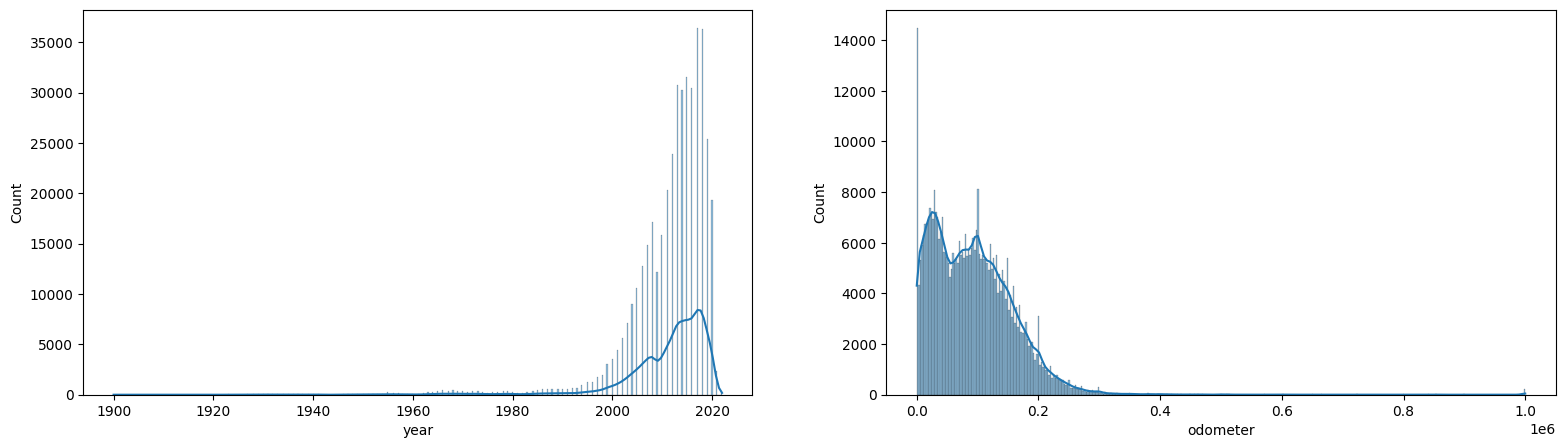

In [24]:
plt.figure (figsize= (19, 5))

for col in na_num_cols:
    plt.subplot (1, 2, na_num_cols.index (col) + 1)
    sns.histplot (data= df, x= col, kde= True)

plt.show ()

In [25]:
print (len (df [df ['year'] == 1900][['price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_index ()))
df [df ['year'] == 1900][['price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_index ()

12


,price,year,manufacturer,model,condition,odometer
29955,1,"1,900.00",NaN,All,fair,"100,000.00"
32544,1,"1,900.00",NaN,All,fair,"100,000.00"
42454,38250,"1,900.00",acura,rdx,new,"4,500.00"
44754,1,"1,900.00",NaN,All,good,"1,000.00"
94319,1,"1,900.00",ford,power wagon,NaN,"2,300.00"
95914,1,"1,900.00",ford,power wagon,NaN,"2,300.00"
96564,1,"1,900.00",ford,power wagon,NaN,"2,300.00"
123023,4500,"1,900.00",NaN,cushman white van,excellent,"2,136.00"
126977,1,"1,900.00",NaN,The earth is flat,good,"123,000.00"
154138,75,"1,900.00",NaN,any and all,NaN,"10,000.00"


## 1900 (year) -> placeholder/garbage

In [26]:
print (len (df [df ['year'] < 1930][['price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_index ()))
df [df ['year'] < 1930][['price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_index ()

246


,price,year,manufacturer,model,condition,odometer
455,22500,"1,929.00",ford,NaN,NaN,NaN
1698,0,"1,903.00",chevrolet,corvette,NaN,NaN
4060,10995,"1,926.00",NaN,1926 nash,NaN,20.00
9653,15000,"1,922.00",ford,t-bucket roadster,good,"80,000.00"
9681,11500,"1,928.00",chevrolet,coupe,fair,"55,752.00"
...,...,...,...,...,...,...
419802,13900,"1,928.00",ford,NaN,NaN,"87,906.00"
422011,26500,"1,925.00",ford,tbucket,excellent,"3,000.00"
424398,18500,"1,929.00",ford,model a,NaN,29.00
426283,14995,"1,929.00",ford,NaN,NaN,"2,000.00"


In [27]:
df[df["year"] < 1920] ['year'].value_counts ()

year
1,903.00    12
1,900.00    12
1,901.00     3
1,916.00     2
1,913.00     2
1,910.00     2
1,918.00     1
1,915.00     1
1,902.00     1
1,905.00     1
1,909.00     1
Name: count, dtype: int64

In [28]:
df.loc[df["year"] == 1900, "year"] = np.nan

In [29]:
task = {
    'columns': ['year'],
    'action': 'df.loc[df["year"] == 1900, "year"] = np.nan'
}

append_to_do (task)

In [30]:
df ['year'].isna ().sum ()

np.int64(1206)

In [31]:
# Median for all of na_num_cols

FILL_METHOD = 'median'

task = {
    "columns": na_num_cols,
    "action": f"fill missing values with {FILL_METHOD}",
}

append_to_do (task)

In [32]:
for col in na_num_cols:
    median = df [col].median ()
    df [col] = df [col].fillna (value= median)

In [33]:
df [na_num_cols].isna ().sum ().sum ()

np.int64(0)

In [34]:
price_zero = df[df["price"] == 0]

price_zero[[
    "price",
    "year",
    "manufacturer",
    "model",
    "condition",
    "odometer"
]].head(50)

,price,year,manufacturer,model,condition,odometer
10,0,"2,013.00",NaN,NaN,NaN,"85,341.00"
46,0,"2,011.00",jeep,compass,excellent,"99,615.00"
126,0,"2,018.00",chevrolet,express cargo van,like new,"68,472.00"
127,0,"2,019.00",chevrolet,express cargo van,like new,"69,125.00"
128,0,"2,018.00",chevrolet,express cargo van,like new,"66,555.00"
191,0,"2,015.00",nissan,sentra,excellent,"99,505.00"
239,0,"2,019.00",chevrolet,silverado 1500,excellent,"25,127.00"
242,0,"2,014.00",NaN,Freightliner Cascadia,NaN,100.00
244,0,"2,017.00",chevrolet,silverado 2500hd 4x4,like new,"102,000.00"
258,0,"2,015.00",mercedes-benz,s-class,NaN,"78,807.00"


In [35]:
df.loc[df["price"] == 0, "price"] = np.nan

In [36]:
df ['price'].isna ().sum ()

np.int64(32889)

In [37]:
task = {
    'columns': ['price'],
    'action': 'df.loc[df["price"] == 0, "price"] = np.nan'
}

append_to_do (task)

### We will not use these nan in train

### DONE ✅

### Categorical Columns

In [38]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: manufacturer
No.of unique values: 42
First 4 unique values: [nan, 'gmc', 'chevrolet', 'toyota']
Mode: ford
Missing %: 4.13%
No.of missing: 17635
--------------------------------------------------

Col name: model
No.of unique values: 29667
First 4 unique values: [nan, 'sierra 1500 crew cab slt', 'silverado 1500', 'silverado 1500 crew']
Mode: f-150
Missing %: 1.23%
No.of missing: 5266
--------------------------------------------------

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: fuel
No.of unique values: 5
First 4 unique values: [nan, 'gas', 'other', 'diesel']
Mode: gas
Missing %: 0.70%


In [39]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    mode = df [col].mode () [0]
    df [col] = df [col].fillna (value= mode)

In [40]:
task = {
    "columns": ['manufacturer', 'fuel', 'title_status', 'transmission'],
    "action": "fill missing values with mode"
}

append_to_do (task)

In [41]:
df [['manufacturer', 'fuel', 'title_status', 'transmission']].isna ().sum ().sum ()

np.int64(0)

In [42]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    print (col)
    print (df [col].unique ().tolist ())
    print ('-' * 50)
    print ()

manufacturer
['ford', 'gmc', 'chevrolet', 'toyota', 'jeep', 'nissan', 'ram', 'mazda', 'cadillac', 'honda', 'dodge', 'lexus', 'jaguar', 'buick', 'chrysler', 'volvo', 'audi', 'infiniti', 'lincoln', 'alfa-romeo', 'subaru', 'acura', 'hyundai', 'mercedes-benz', 'bmw', 'mitsubishi', 'volkswagen', 'porsche', 'kia', 'rover', 'ferrari', 'mini', 'pontiac', 'fiat', 'tesla', 'saturn', 'mercury', 'harley-davidson', 'datsun', 'aston-martin', 'land rover', 'morgan']
--------------------------------------------------

fuel
['gas', 'other', 'diesel', 'hybrid', 'electric']
--------------------------------------------------

title_status
['clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
--------------------------------------------------

transmission
['automatic', 'other', 'manual']
--------------------------------------------------



In [43]:
for col in ['manufacturer', 'fuel', 'title_status', 'transmission']:
    if col in na_cat_cols:
        na_cat_cols.remove (col)
print (na_cat_cols)


['model', 'condition', 'cylinders', 'drive', 'type', 'paint_color', 'posting_date']


In [44]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: model
No.of unique values: 29667
First 4 unique values: [nan, 'sierra 1500 crew cab slt', 'silverado 1500', 'silverado 1500 crew']
Mode: f-150
Missing %: 1.23%
No.of missing: 5266
--------------------------------------------------

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: drive
No.of unique values: 3
First 4 unique values: [nan, 'rwd', '4wd', 'fwd']
Mode: 4wd
Missing %: 30.59%
No.of missing: 130550
--------------------------------------------------

Col name: type
No.of unique values: 13
First 4 unique values: [nan, 'pickup', 'truck', 'other']
Mode: sedan
Missing %: 21.75%
No.of miss

In [45]:
df ["model"].nunique ()

29667

In [46]:
df ['model'].sample (5)

309743                      soul
123707           g g37x sedan 4d
413203    fj cruiser 4x4 gas suv
297375     commander limited 4x4
243649                   mustang
Name: model, dtype: object

In [47]:
df ["model"] = df ["model"].astype (str)

In [48]:
print ([x for x in df ['model'].unique ().tolist () if len (x) < 5])

['nan', 'f450', 'tlx', 'z4', 'rav4', 'f150', 'benz', 'echo', '525i', 'f750', '300m', 'f100', 'soul', 'srx', 'x3', 'sts', 'tl', '2500', 'edge', '1500', 'qx30', 'cls', 's60', 'jx35', '3500', '300', 'mdx', 'q7', 'trax', 'hhr', 'q50', 'x6', 'ex35', 'baja', '1988', 'tsx', 'mkz', '328i', 'x5', 'cr v', 'qx4', 'rx', '200', 'xj', 'f250', 'fx35', 'f550', 'rio', 'r XF', 'cx-5', 'rl', 'glk', 'q60', 'm35', 'is', 'cj7', 'e350', '3i', '4500', '5500', 'qx70', 'gx', 'mkc', 'cts', '300c', 'kona', 'CX-5', 'cr-v', '560', 'sl', 'juke', 'dart', '500', 'HINO', '535i', 'acty', 's80', 'ssr', 'rdx', 'a3', 'qx80', 'xts', 'e250', 'mkx', 'rc', 'a5', 'aura', 'es', 'all', '2', 'ls', 'dts', 'c10', 'f800', 'qx60', 's10', 'c20', 'Nash', '210', 'w150', 'rsx', 'flex', 'f350', 'q5', 'a4', '370z', 'm37', 'xlr', 'crx', 'cc', 'l300', 'hse', 'xc90', '530i', 'lr4', 'vibe', 'c250', 'ilx', '650i', 'qx56', 'hrv', '2001', 'g6', 'a6', 's500', 'e450', 'xk8', '5', 'hr-v', 'xt5', 'x1', 'ion', 'crv', 'ats', 'cx-3', 'i30', 'c230', '3', 

In [49]:
missing_values = [
    'nan',

    'all', 'All', 'ALL', 'any', 'Any', 'ANY',
    'NONE', 'etc', 'etc.', 'also', 'many',

    'New', 'car', 'Car', 'cars', 'You',
    'Xxx', 'Xx', 'junk', 'Junk', 'inc',

    '%', ':', '-', '.', '♿', '0', '1234', 'll', 'ak',

    'p', 'a', 'A', 'c', 'C', 'e', 'f', 'g', 'G', 'h',
    'H', 'i', 'm', 'N', 'O', 'R', 's', 't', 'v', 'x', 'z',

    'any and all'
]

df['model'] = df['model'].replace (missing_values, np.nan)


In [50]:
task = {
    "columns": ['model'],
    "action": "Replace all garbage values (name of the list is missing_values) with actual nan"
}

append_to_do (task)


In [51]:
print (f"Missing %: {df ['model'].isna ().sum () / len (df) * 100:.2f}%")
print (f'No.of missing:', df ['model'].isna ().sum ())



Missing %: 1.34%
No.of missing: 5734


In [52]:
df ["model"].value_counts (dropna= True).head (10)

model
f-150             8008
silverado 1500    5140
1500              4211
camry             3134
silverado         3022
accord            2969
wrangler          2848
civic             2799
altima            2779
escape            2746
Name: count, dtype: int64

In [53]:
df ['model'] = df ['model'].fillna (value= "Unknown")

In [54]:
df ['model'].isna ().sum ()

np.int64(0)

In [55]:
if 'model' in na_cat_cols:
    na_cat_cols.remove ('model')
print (na_cat_cols)

['condition', 'cylinders', 'drive', 'type', 'paint_color', 'posting_date']


In [56]:
for col in na_cat_cols:
    print ('Col name:', col)
    print ('No.of unique values:', len (df [col].unique ()) - 1)
    print ('First 4 unique values:', df [col].unique ().tolist () [: 4])
    print ("Mode:", df [col].mode () [0])
    print (f"Missing %: {df [col].isna ().sum () / len (df) * 100:.2f}%")
    print (f'No.of missing:', df [col].isna ().sum ())
    print ('-' * 50)
    print ()

Col name: condition
No.of unique values: 6
First 4 unique values: [nan, 'good', 'excellent', 'fair']
Mode: good
Missing %: 40.78%
No.of missing: 174080
--------------------------------------------------

Col name: cylinders
No.of unique values: 8
First 4 unique values: [nan, '8 cylinders', '6 cylinders', '4 cylinders']
Mode: 6 cylinders
Missing %: 41.62%
No.of missing: 177654
--------------------------------------------------

Col name: drive
No.of unique values: 3
First 4 unique values: [nan, 'rwd', '4wd', 'fwd']
Mode: 4wd
Missing %: 30.59%
No.of missing: 130550
--------------------------------------------------

Col name: type
No.of unique values: 13
First 4 unique values: [nan, 'pickup', 'truck', 'other']
Mode: sedan
Missing %: 21.75%
No.of missing: 92847
--------------------------------------------------

Col name: paint_color
No.of unique values: 12
First 4 unique values: [nan, 'white', 'blue', 'red']
Mode: white
Missing %: 30.50%
No.of missing: 130181
----------------------------

In [57]:
df.dropna (subset= ['posting_date'], inplace= True) # 57 Only

if 'posting_date' in na_cat_cols:
    na_cat_cols.remove ('posting_date')

for col in na_cat_cols:
    df [col] = df [col].fillna ("Unknown")

In [58]:
task = {
    'columns': ['posting_date'],
    'action': 'dropna'
}

append_to_do (task)


task = {
    'columns': ['model', 'condition', 'cylinders', 'drive', 'type', 'paint_color'],
    'action': 'fillna with Unknown'
}

append_to_do (task)


In [59]:
df.head ()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
27,auburn,"33,590.00","2,014.00",gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,"57,923.00",clean,other,Unknown,pickup,white,al,2021-05-04T12:31:18-0500
28,auburn,"22,590.00","2,010.00",chevrolet,silverado 1500,good,8 cylinders,gas,"71,229.00",clean,other,Unknown,pickup,blue,al,2021-05-04T12:31:08-0500
29,auburn,"39,590.00","2,020.00",chevrolet,silverado 1500 crew,good,8 cylinders,gas,"19,160.00",clean,other,Unknown,pickup,red,al,2021-05-04T12:31:25-0500
30,auburn,"30,990.00","2,017.00",toyota,tundra double cab sr,good,8 cylinders,gas,"41,124.00",clean,other,Unknown,pickup,red,al,2021-05-04T10:41:31-0500
31,auburn,"15,000.00","2,013.00",ford,f-150 xlt,excellent,6 cylinders,gas,"128,000.00",clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500


In [60]:
print ("No.of Lost rows:", num_of_rows - df.shape [0])
print ("Lost %:", (num_of_rows - df.shape [0]) / num_of_rows * 100)

No.of Lost rows: 96
Lost %: 0.022488755622188904


## Analyze Target

In [61]:
df ["price"].describe ()

count         393,896.00
mean           81,492.62
std        12,682,069.35
min                 1.00
25%             7,000.00
50%            15,000.00
75%            27,590.00
max     3,736,928,711.00
Name: price, dtype: float64

# 3.7 billions for a car 🫨🫨🫨🫨🫨

In [62]:
(df ["price"] > 500_000).sum ()

np.int64(68)

In [63]:
(df ["price"] > 500_000).mean () * 100

np.float64(0.01593311839244208)

In [64]:
df [df ["price"] > 500_000]["price"].value_counts ()

price
1,234,567.00        13
1,000,000.00         7
123,456,789.00       6
12,345,678.00        6
1,111,111.00         5
987,654,321.00       2
3,024,942,282.00     2
3,736,928,711.00     2
777,777.00           2
1,111,111,111.00     2
990,000.00           1
655,000.00           1
2,000,000.00         1
3,009,548,743.00     1
99,999,999.00        1
566,567.00           1
17,000,000.00        1
516,999.00           1
6,995,495.00         1
135,008,900.00       1
1,234,567,890.00     1
1,410,065,407.00     1
554,900.00           1
1,666,666.00         1
5,000,000.00         1
113,456,789.00       1
10,004,000.00        1
3,226,714.00         1
11,111,111.00        1
25,003,000.00        1
999,999.00           1
Name: count, dtype: int64

In [65]:
print (df[df["price"] > 500_000]["price"].unique ().tolist ())

[987654321.0, 99999999.0, 1111111.0, 1111111111.0, 3009548743.0, 2000000.0, 655000.0, 1000000.0, 3024942282.0, 990000.0, 6995495.0, 516999.0, 17000000.0, 123456789.0, 566567.0, 1234567890.0, 1234567.0, 1410065407.0, 554900.0, 135008900.0, 113456789.0, 5000000.0, 1666666.0, 12345678.0, 10004000.0, 777777.0, 3736928711.0, 3226714.0, 11111111.0, 25003000.0, 999999.0]


### I see these numbers is weird

In [66]:
task = {
    'columns': ['price'],
    'action': 'drop all values that greater than 500_000'
}


append_to_do (task)

In [67]:
df = df[(df["price"] <= 500_000) | (df["price"].isna())]

In [68]:
(df["price"] > 500_000).sum ()

np.int64(0)

In [69]:
df ['price'].describe ()

count   393,828.00
mean     18,902.74
std      15,398.28
min           1.00
25%       7,000.00
50%      15,000.00
75%      27,590.00
max     470,000.00
Name: price, dtype: float64

In [70]:
df ['price'].isna ().sum ()

np.int64(32888)

## Detect & Handle Outliers

In [71]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
Index: 426716 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426716 non-null  object 
 1   price         393828 non-null  float64
 2   year          426716 non-null  float64
 3   manufacturer  426716 non-null  object 
 4   model         426716 non-null  object 
 5   condition     426716 non-null  object 
 6   cylinders     426716 non-null  object 
 7   fuel          426716 non-null  object 
 8   odometer      426716 non-null  float64
 9   title_status  426716 non-null  object 
 10  transmission  426716 non-null  object 
 11  drive         426716 non-null  object 
 12  type          426716 non-null  object 
 13  paint_color   426716 non-null  object 
 14  state         426716 non-null  object 
 15  posting_date  426716 non-null  object 
dtypes: float64(3), object(13)
memory usage: 55.3+ MB


In [72]:
num_cols = df.select_dtypes (include= "number").columns.tolist ()
num_cols

['price', 'year', 'odometer']

In [73]:
def check_outliers(
    data, column,
    specific_lower : bool = False, lower_bound : float = 0.0,
    specific_upper : bool = False, upper_bound : float = 0.0
    ):
    q1 = data [column].quantile (0.25)
    q3 = data [column].quantile (0.75)

    iqr = q3 - q1

    if specific_lower:
        lower = lower_bound
    else:
        lower = q1 - 1.5 * iqr

    if specific_upper:
        upper = upper_bound
    else:
        upper = q3 + 1.5 * iqr

    outliers = data[
        (data [column] < lower) |
        (data [column] > upper)
    ]

    print(f"Column: {column}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")
    print(f"Outliers: {len(outliers):,}")
    print(f"Percentage: {len(outliers) / len(data) * 100:.2f}%")

In [74]:
num_cols

['price', 'year', 'odometer']

Column: price
Q1: 7000.00
Q3: 27590.00
IQR: 20590.00
Lower Bound: 0.00
Upper Bound: 58475.00
Outliers: 7,709
Percentage: 1.81%


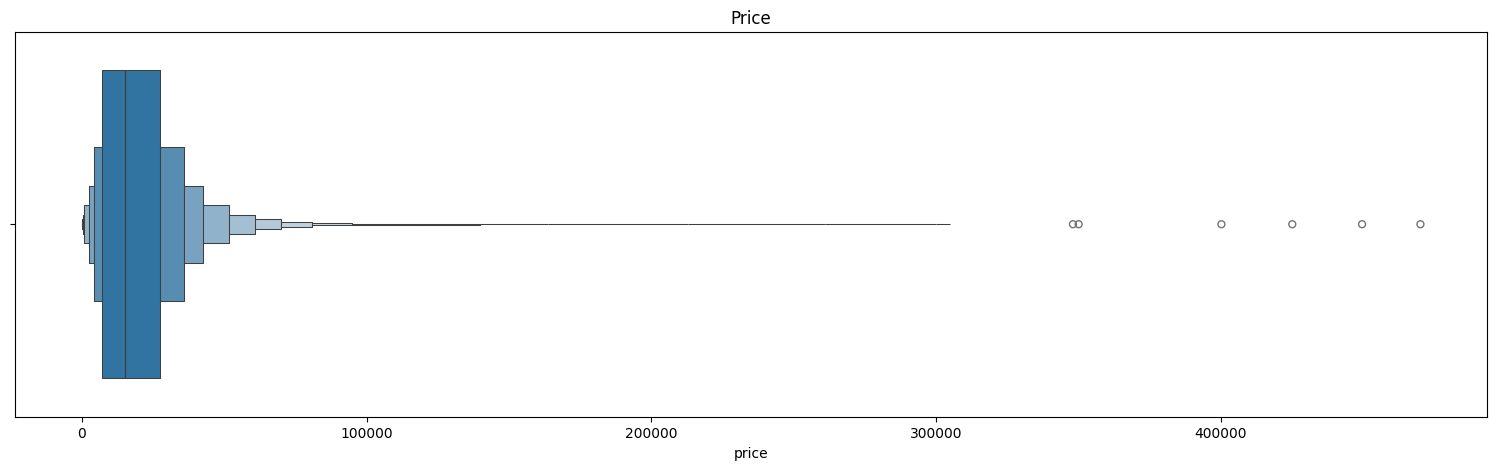

In [75]:
### Price
check_outliers (df, "price", specific_lower= True, lower_bound= 0.0)
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'price')
plt.title ('Price')
plt.show ()

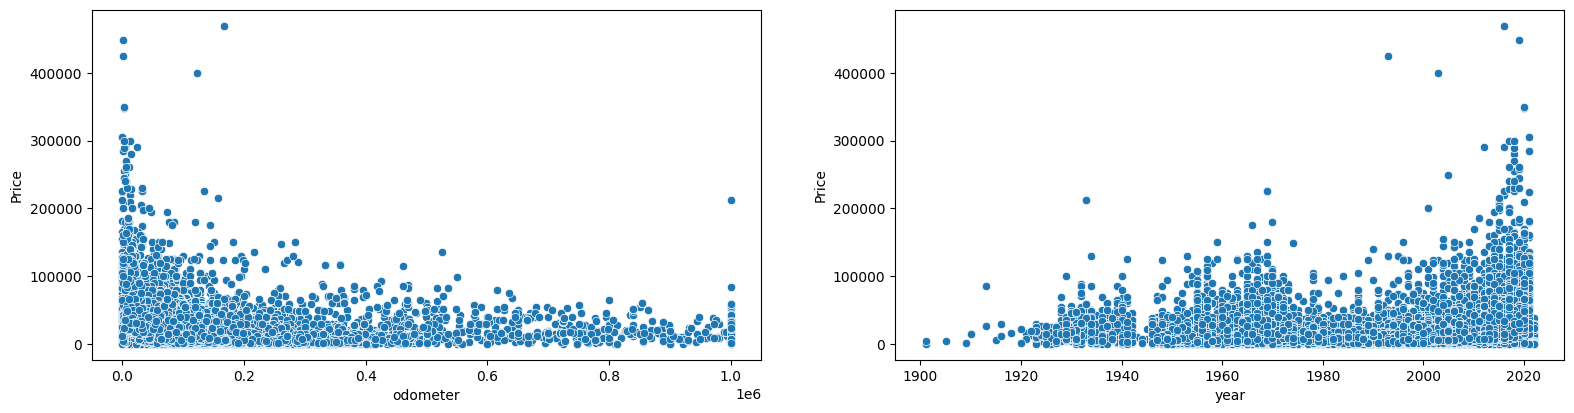

In [76]:
plt.figure (figsize= (19, 10))

cols= ['odometer', 'year']

for col in cols:
    plt.subplot (2, 2, cols.index (col) + 1)
    sns.scatterplot (data= df, x= col, y= 'price')
    plt.xlabel (col)
    plt.ylabel ('Price')


plt.show ()

In [77]:
# Look closer at the high-price outliers before deciding what to drop
print ("No.of cars over 300,000:", sum (df [df ['price'] > 300_000] ['price'].value_counts ()))
df [df ['price'] > 300_000] [
    ["price", "year", "manufacturer", "model", "condition", "odometer"]
]

No.of cars over 300,000: 9


,price,year,manufacturer,model,condition,odometer
44387,"347,999.00","2,020.00",ferrari,f8 tributo,excellent,"3,000.00"
45428,"349,999.00","2,020.00",ferrari,f8 tributo,excellent,"2,800.00"
88588,"304,995.00","2,021.00",porsche,911,Unknown,22.00
90274,"304,995.00","2,021.00",porsche,911,Unknown,22.00
113357,"470,000.00","2,016.00",ford,hINO 268,good,"167,268.00"
133497,"425,000.00","1,993.00",jeep,wrangler,Unknown,380.00
328193,"400,123.00","2,003.00",ford,Unknown,fair,"123,321.00"
360604,"449,500.00","2,019.00",ferrari,488 gtb,Unknown,500.00
399462,"304,995.00","2,021.00",porsche,911,Unknown,22.00


In [78]:
# These two specifically don't add up:
# - manufacturer says "ford" but model is "hINO 268" (Hino is a truck brand, not a Ford model)
# - a 1993 Jeep Wrangler with only 380 miles at $425,000 (too old + too little mileage + too expensive together)
suspicious_rows = [113357, 133497]
df.loc[suspicious_rows].T

,113357,133497
region,south florida,east idaho
price,"470,000.00","425,000.00"
year,"2,016.00","1,993.00"
manufacturer,ford,jeep
model,hINO 268,wrangler
condition,good,Unknown
cylinders,Unknown,Unknown
fuel,diesel,gas
odometer,"167,268.00",380.00
title_status,clean,clean


In [79]:
df = df.drop (index= suspicious_rows)

In [80]:
task = {
    'columns': ['price'],
    'action': 'drop suspicious rows: [113357, 133497]'
}
append_to_do (task)

### Year

In [81]:
df ['year'].describe ()

count   426,714.00
mean      2,011.25
std           9.41
min       1,901.00
25%       2,008.00
50%       2,013.00
75%       2,017.00
max       2,022.00
Name: year, dtype: float64

Column: year
Q1: 2008.00
Q3: 2017.00
IQR: 9.00
Lower Bound: 1994.50
Upper Bound: 2030.50
Outliers: 15,860
Percentage: 3.72%


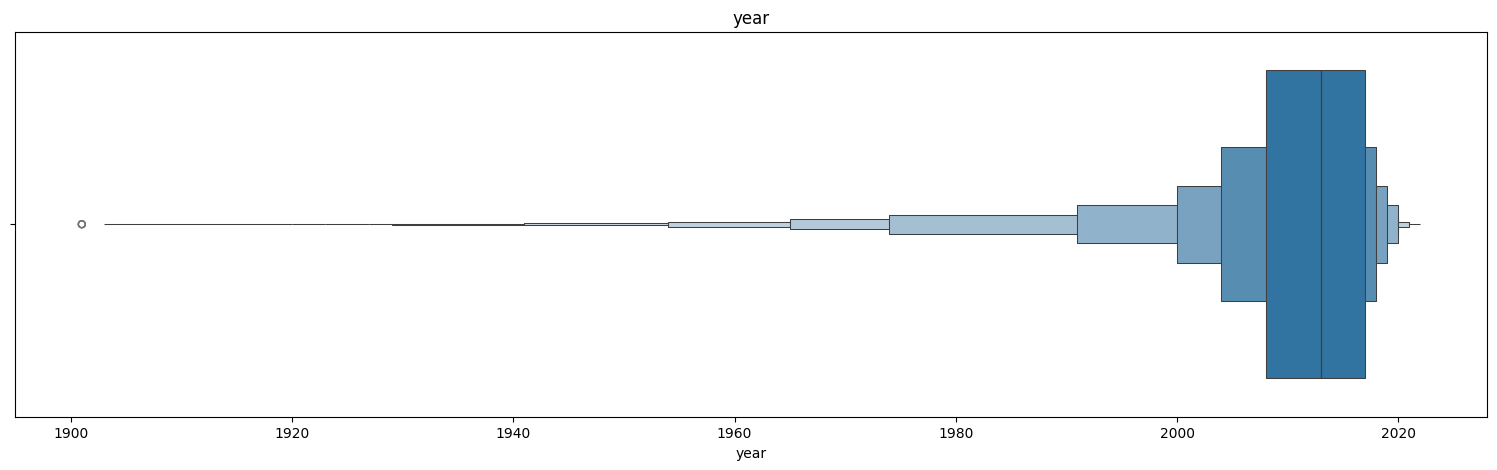

In [82]:
check_outliers (df, "year")
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'year')
plt.title ('year')
plt.show ()

In [83]:
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())

Minimum year: 1901.0
Maximum year: 2022.0


In [84]:
Q1 = df["year"].quantile(0.25)
Q3 = df["year"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

year_outliers = df[
    (df["year"] < lower_bound) |
    (df["year"] > upper_bound)
]

year_outliers.sample (5)

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
343582,rhode island,"18,500.00","1,923.00",ford,t-bucket,excellent,8 cylinders,gas,"2,500.00",clean,automatic,rwd,convertible,Unknown,ri,2021-04-09T19:53:05-0400
144262,"quad cities, IA/IL","3,000.00","1,982.00",ford,country squire,Unknown,Unknown,gas,"102,000.00",clean,automatic,Unknown,Unknown,Unknown,il,2021-04-10T18:26:27-0500
34606,los angeles,"4,000.00","1,975.00",ford,ranchero gt,good,8 cylinders,gas,"72,828.00",clean,automatic,fwd,wagon,white,ca,2021-05-02T19:40:26-0700
104134,orlando,"59,500.00","1,972.00",chevrolet,c10,Unknown,8 cylinders,gas,"999,999.00",clean,automatic,Unknown,Unknown,Unknown,fl,2021-05-04T17:08:37-0400
159963,mason city,"8,500.00","1,972.00",ford,mustang,Unknown,Unknown,gas,"100,000.00",clean,automatic,Unknown,Unknown,Unknown,ia,2021-04-18T09:08:37-0500


In [85]:
len (df [df ['year'] < 2008])

93175

In [86]:
['odometer']

['odometer']

Column: odometer
Q1: 38123.00
Q3: 132500.00
IQR: 94377.00
Lower Bound: 0.00
Upper Bound: 274065.50
Outliers: 3,949
Percentage: 0.93%


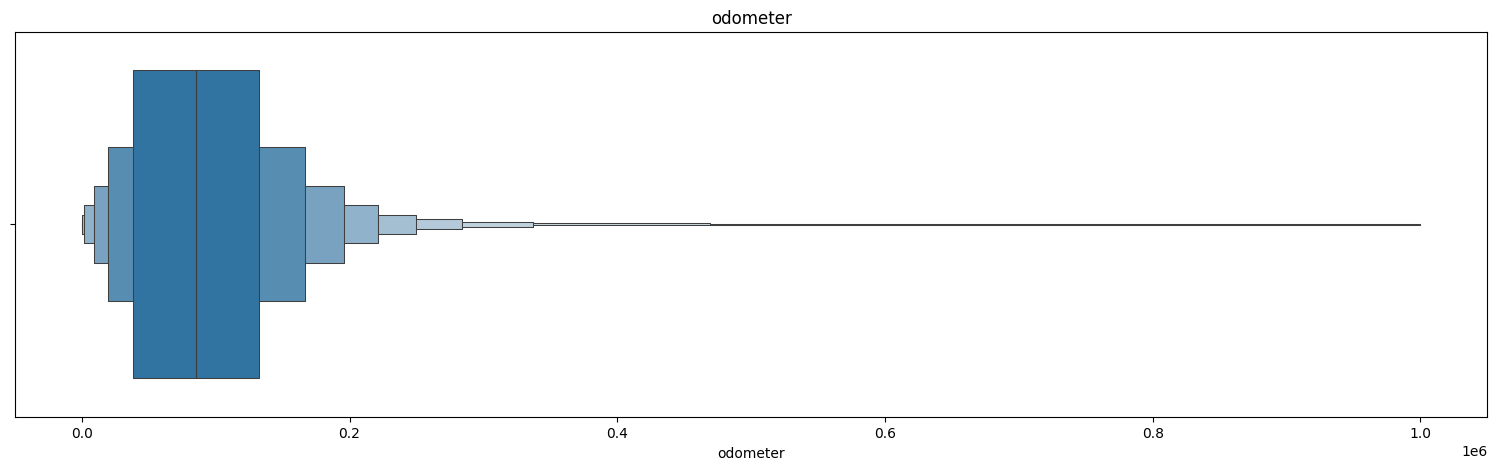

In [87]:
check_outliers (df, "odometer", specific_lower= True, lower_bound= 0.0)
plt.figure (figsize= (19, 5))
sns.boxenplot (data= df, x= 'odometer')
plt.title ('odometer')
plt.show ()

In [88]:
df["odometer"].describe ()

count   426,714.00
mean     92,440.87
std      70,214.33
min           0.00
25%      38,123.00
50%      85,341.00
75%     132,500.00
max     999,999.00
Name: odometer, dtype: float64

In [89]:
for x in to_do:
    pprint (x)
    print ('-' * 20)
    print ()

{'action': 'drop useless columns',
 'columns': ['id',
             'url',
             'region_url',
             'VIN',
             'image_url',
             'description',
             'county',
             'lat',
             'long']}
--------------------

{'action': 'drop duplicates',
 'columns': ['region',
             'price',
             'year',
             'manufacturer',
             'model',
             'condition',
             'cylinders',
             'fuel',
             'odometer',
             'title_status',
             'transmission',
             'drive',
             'size',
             'type',
             'paint_color',
             'state',
             'posting_date']}
--------------------

{'action': 'df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan',
 'columns': ['odometer']}
--------------------

{'action': 'df.loc[df["year"] == 1900, "year"] = np.nan', 'columns': ['year']}
--------------------

{'action': 'fill missing values with median', 'co

In [90]:
print (df.shape)
num_of_rows - df.shape [0]

(426714, 16)


166

## EDA

#### Target (price)

In [91]:
price_ranges = pd.cut(
    df["price"],
    bins=[0, 10_000, 20_000, 30_000, 50_000, 100_000, float("inf")],
    labels=[
        "1–10K",
        "10K–20K",
        "20K–30K",
        "30K–50K",
        "50K–100K",
        "100K+"
    ]
)

price_ranges.value_counts().sort_index()

price
1–10K       143297
10K–20K     102273
20K–30K      69541
30K–50K      65852
50K–100K     12278
100K+          585
Name: count, dtype: int64

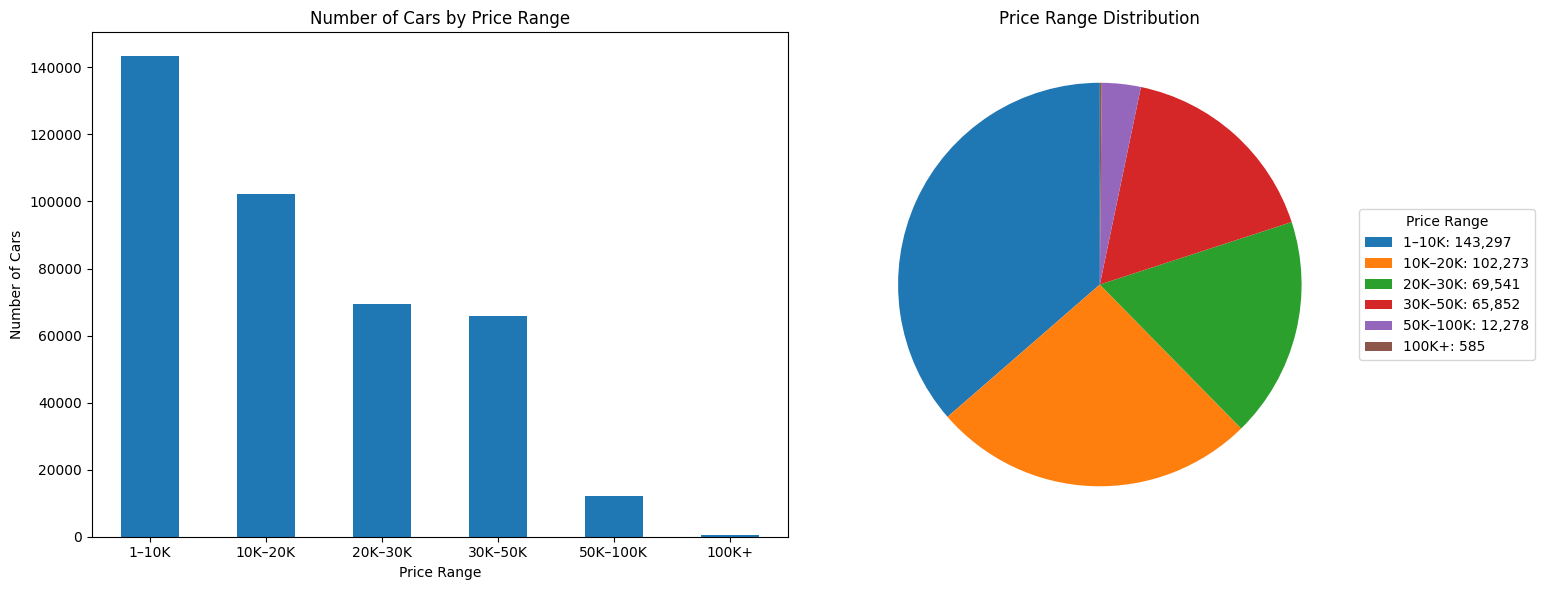

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts = price_ranges.value_counts().sort_index()

# Bar chart
counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Number of Cars")
axes[0].set_title("Number of Cars by Price Range")
axes[0].tick_params(axis="x", rotation=0)


# Pie chart
wedges, _ = axes[1].pie(
    counts,
    startangle=90
)

labels = [
    f"{label}: {count:,}"
    for label, count in zip(counts.index, counts.values)
]

axes[1].legend(
    wedges,
    labels,
    title="Price Range",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

axes[1].set_title("Price Range Distribution")

plt.tight_layout()
plt.show()

### Year

In [93]:
year_ranges = pd.cut(
    df["year"],
    bins=[1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980,
          1990, 2000, 2010, 2020, 2030],
    labels=[
        "1901–1910",
        "1911–1920",
        "1921–1930",
        "1931–1940",
        "1941–1950",
        "1951–1960",
        "1961–1970",
        "1971–1980",
        "1981–1990",
        "1991–2000",
        "2001–2010",
        "2011–2020",
        "2021–2030"
    ]
)

year_range_counts = year_ranges.value_counts().sort_index()

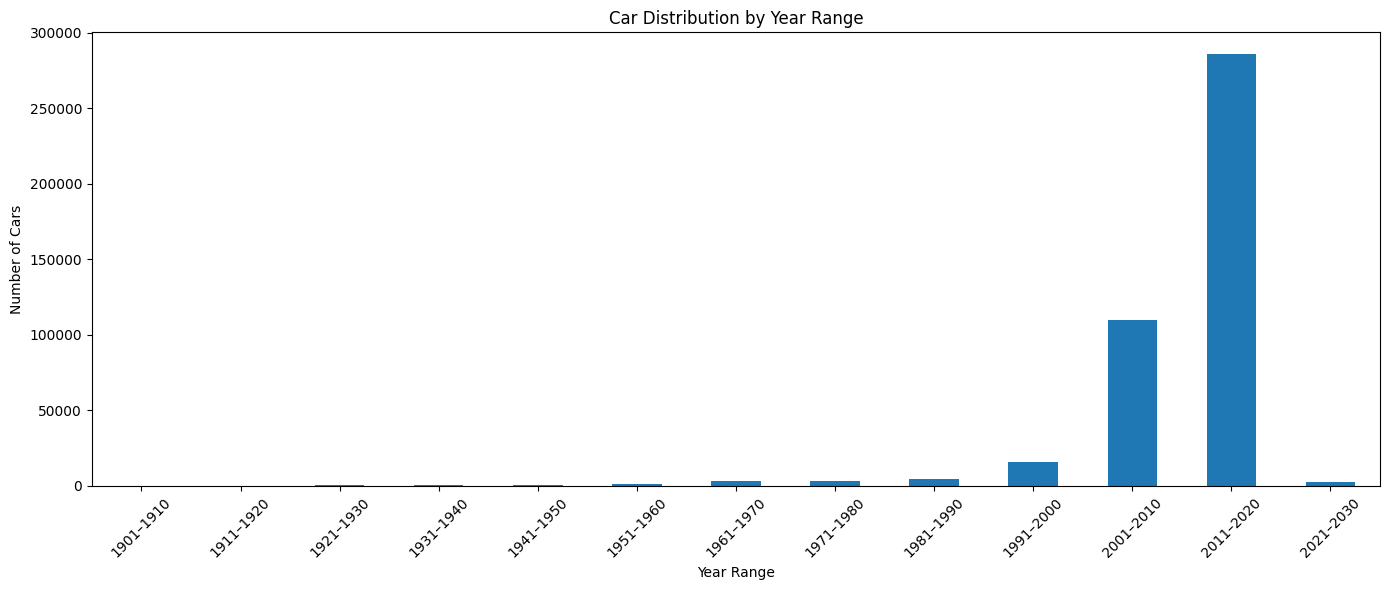

In [94]:
plt.figure(figsize=(14, 6))

year_range_counts.plot(kind="bar")

plt.xlabel("Year Range")
plt.ylabel("Number of Cars")
plt.title("Car Distribution by Year Range")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Year VS avg prices

In [95]:
year_price = (
    df.groupby(year_ranges, observed=True)["price"]
      .mean()
)

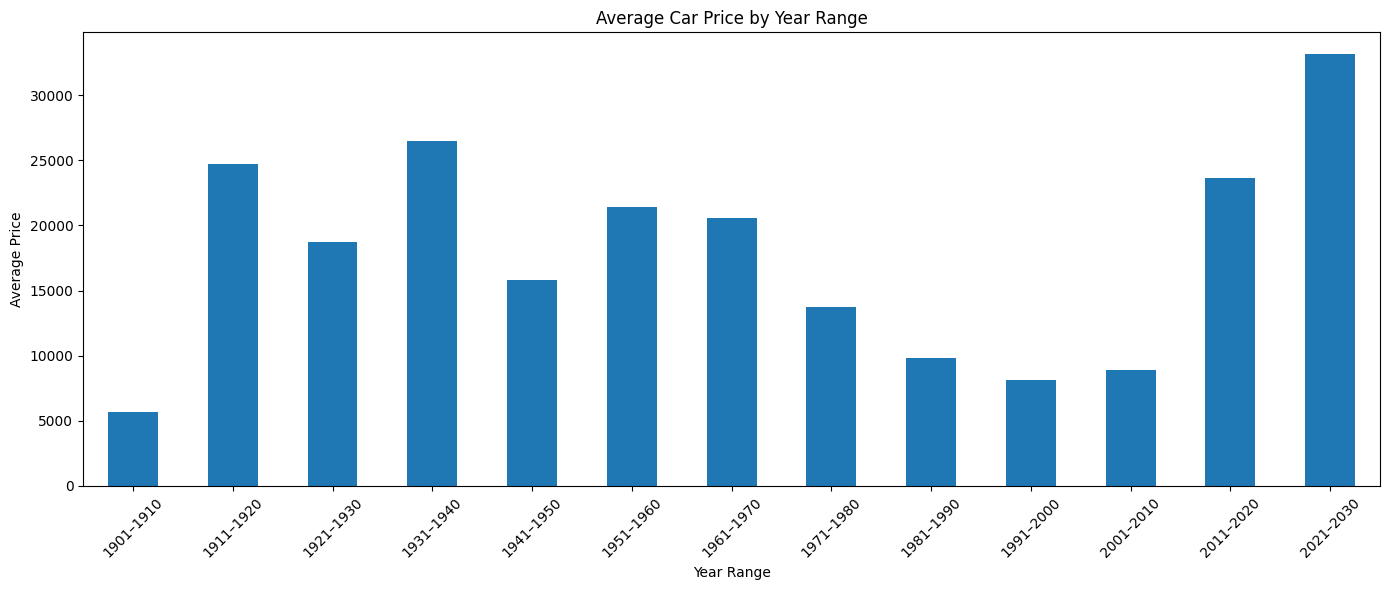

In [96]:
plt.figure(figsize=(14, 6))

year_price.plot(kind="bar")

plt.xlabel("Year Range")
plt.ylabel("Average Price")
plt.title("Average Car Price by Year Range")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Odometer VS avg price

In [97]:
odometer_ranges = pd.cut(
    df["odometer"],
    bins=[0, 50_000, 100_000, 150_000, 200_000, 300_000, 1_000_000],
    labels=[
        "0–50K",
        "50K–100K",
        "100K–150K",
        "150K–200K",
        "200K–300K",
        "300K+"
    ]
)

odometer_price = (
    df.groupby(odometer_ranges, observed=True)["price"]
      .mean()
)

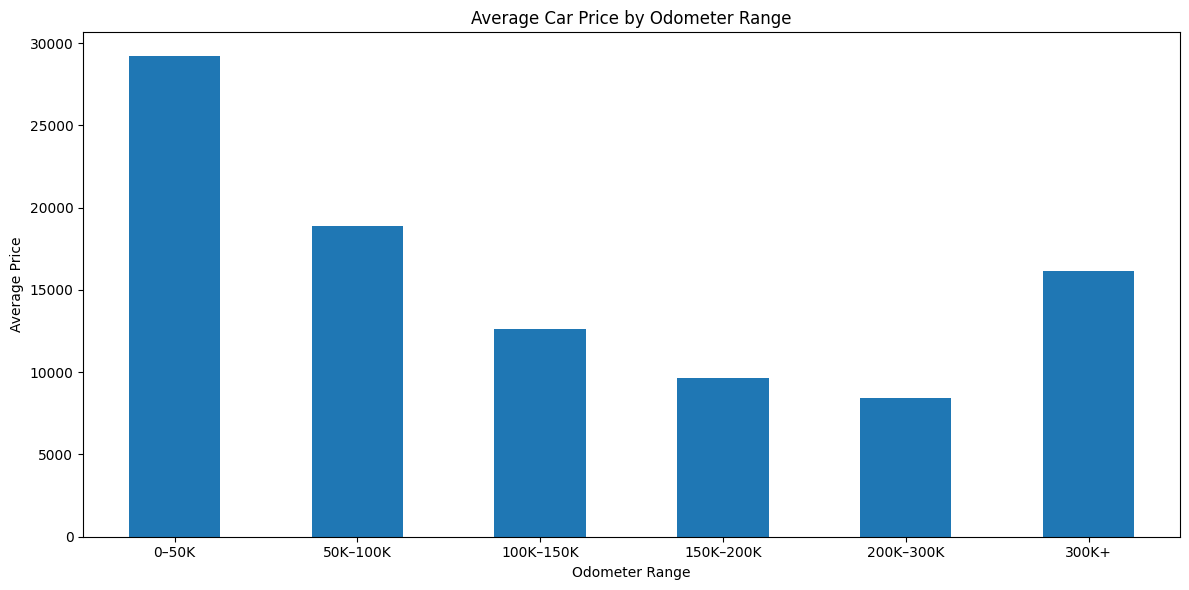

In [98]:
plt.figure(figsize=(12, 6))

odometer_price.plot(kind="bar")

plt.xlabel("Odometer Range")
plt.ylabel("Average Price")
plt.title("Average Car Price by Odometer Range")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Year VS Price
### odometer VS Price

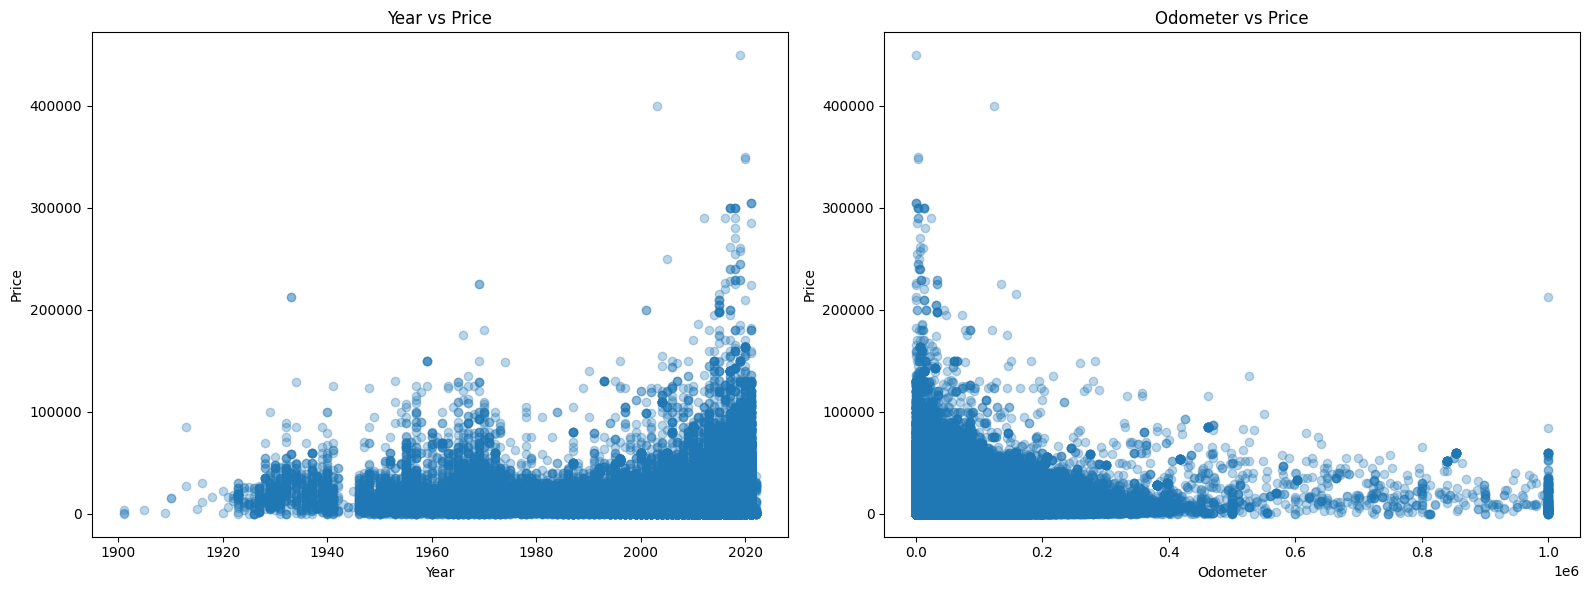

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Year vs Price
axes[0].scatter(
    df["year"],
    df["price"],
    alpha=0.3
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price")
axes[0].set_title("Year vs Price")


# Odometer vs Price
axes[1].scatter(
    df["odometer"],
    df["price"],
    alpha=0.3
)

axes[1].set_xlabel("Odometer")
axes[1].set_ylabel("Price")
axes[1].set_title("Odometer vs Price")


plt.tight_layout()
plt.show()

## Categorical coulmns

In [100]:
manufacturer_price = (
    df.groupby("manufacturer")["price"]
      .mean()
      .sort_values(ascending=False)
)

In [101]:
manufacturer_counts = df["manufacturer"].value_counts()

manufacturer_counts.head(15)

manufacturer
ford             88536
chevrolet        55032
toyota           34197
honda            21269
nissan           19065
jeep             19009
ram              18340
gmc              16781
bmw              14698
dodge            13705
mercedes-benz    11814
hyundai          10336
subaru            9495
volkswagen        9344
kia               8457
Name: count, dtype: int64

In [102]:
top_manufacturers = manufacturer_counts.head(15).index

top_manufacturer_price = (
    df[df["manufacturer"].isin(top_manufacturers)]
    .groupby("manufacturer")["price"]
    .mean()
    .sort_values(ascending=False)
)

top_manufacturer_price

manufacturer
ram             29,859.75
gmc             24,978.67
mercedes-benz   22,215.23
ford            20,848.79
bmw             20,343.30
chevrolet       19,946.07
jeep            19,642.27
toyota          17,072.78
dodge           15,973.34
subaru          13,795.02
volkswagen      13,168.38
nissan          12,874.31
kia             12,419.73
hyundai         11,822.50
honda           11,510.08
Name: price, dtype: float64

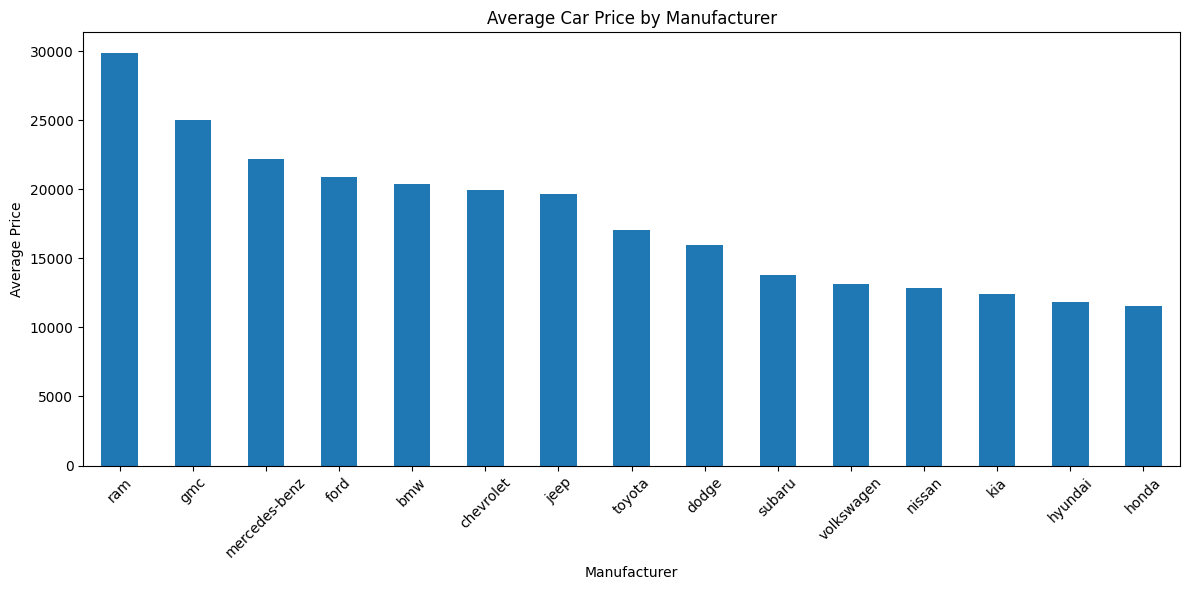

In [103]:
plt.figure(figsize=(12, 6))

top_manufacturer_price.plot(kind="bar")

plt.xlabel("Manufacturer")
plt.ylabel("Average Price")
plt.title("Average Car Price by Manufacturer")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [104]:
condition_price = (
    df.groupby("condition")["price"]
      .mean()
      .sort_values(ascending=False)
)

condition_price

condition
new         27,272.73
good        20,968.22
Unknown     20,006.36
like new    19,248.72
excellent   15,513.79
fair         4,094.01
salvage      3,641.89
Name: price, dtype: float64

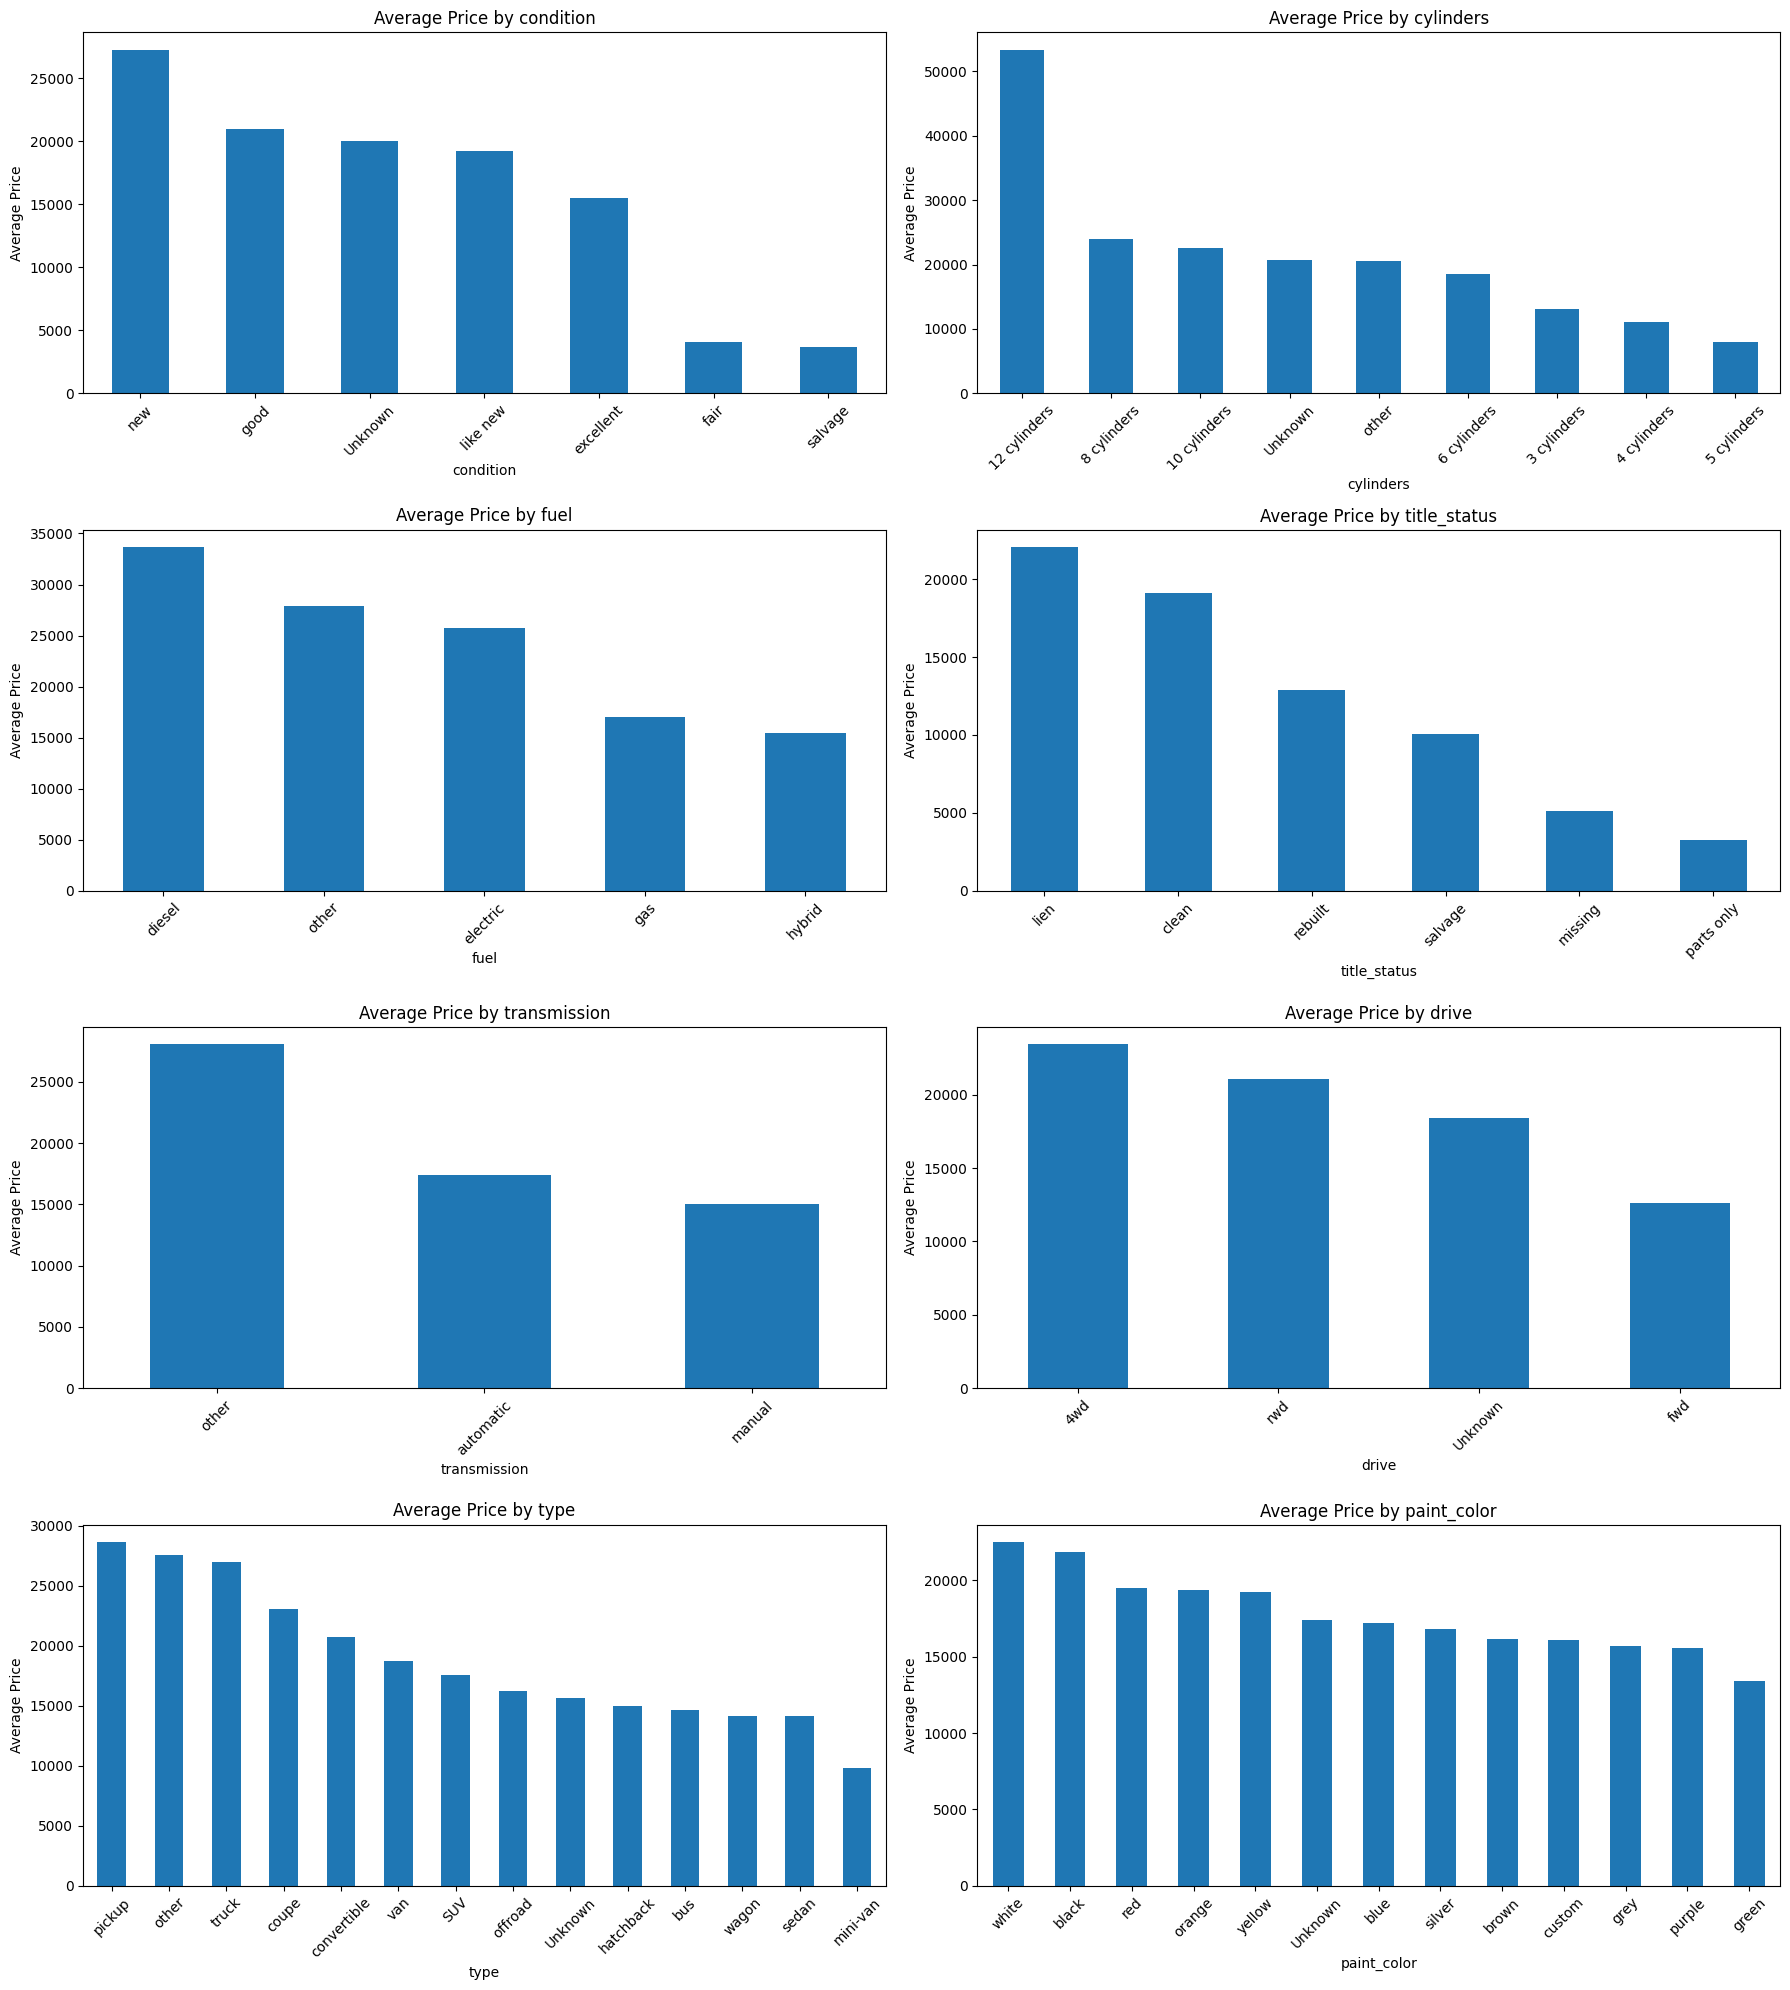

In [105]:
categorical_cols = [
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color'
]

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    avg_price = (
        df.groupby(col)["price"]
          .mean()
          .sort_values(ascending=False)
    )

    avg_price.plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"Average Price by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Average Price")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

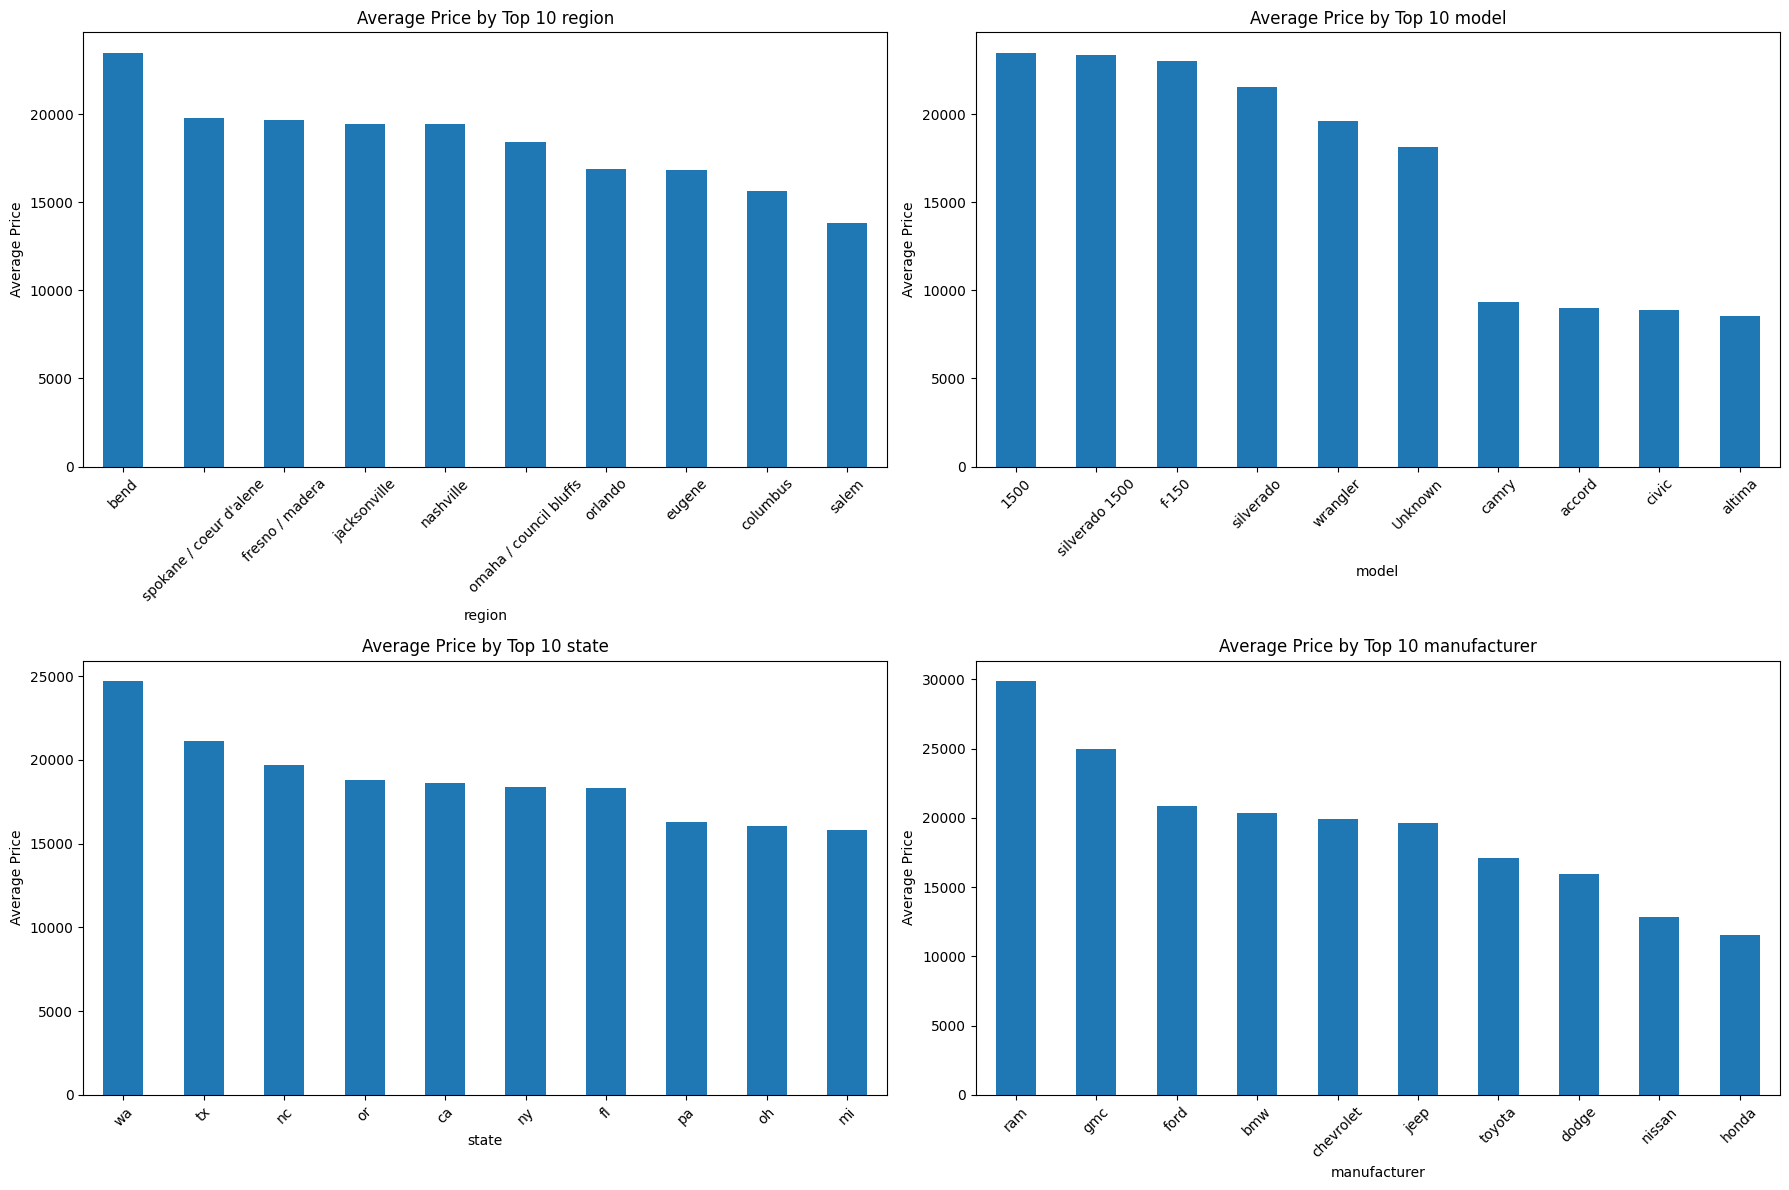

In [106]:
high_cardinality_cols = [
    'region',
    'model',
    'state',
    'manufacturer'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(high_cardinality_cols):

    top_10 = df[col].value_counts().head(10).index

    avg_price = (
        df[df[col].isin(top_10)]
        .groupby(col)["price"]
        .mean()
        .sort_values(ascending=False)
    )

    avg_price.plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"Average Price by Top 10 {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Average Price")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

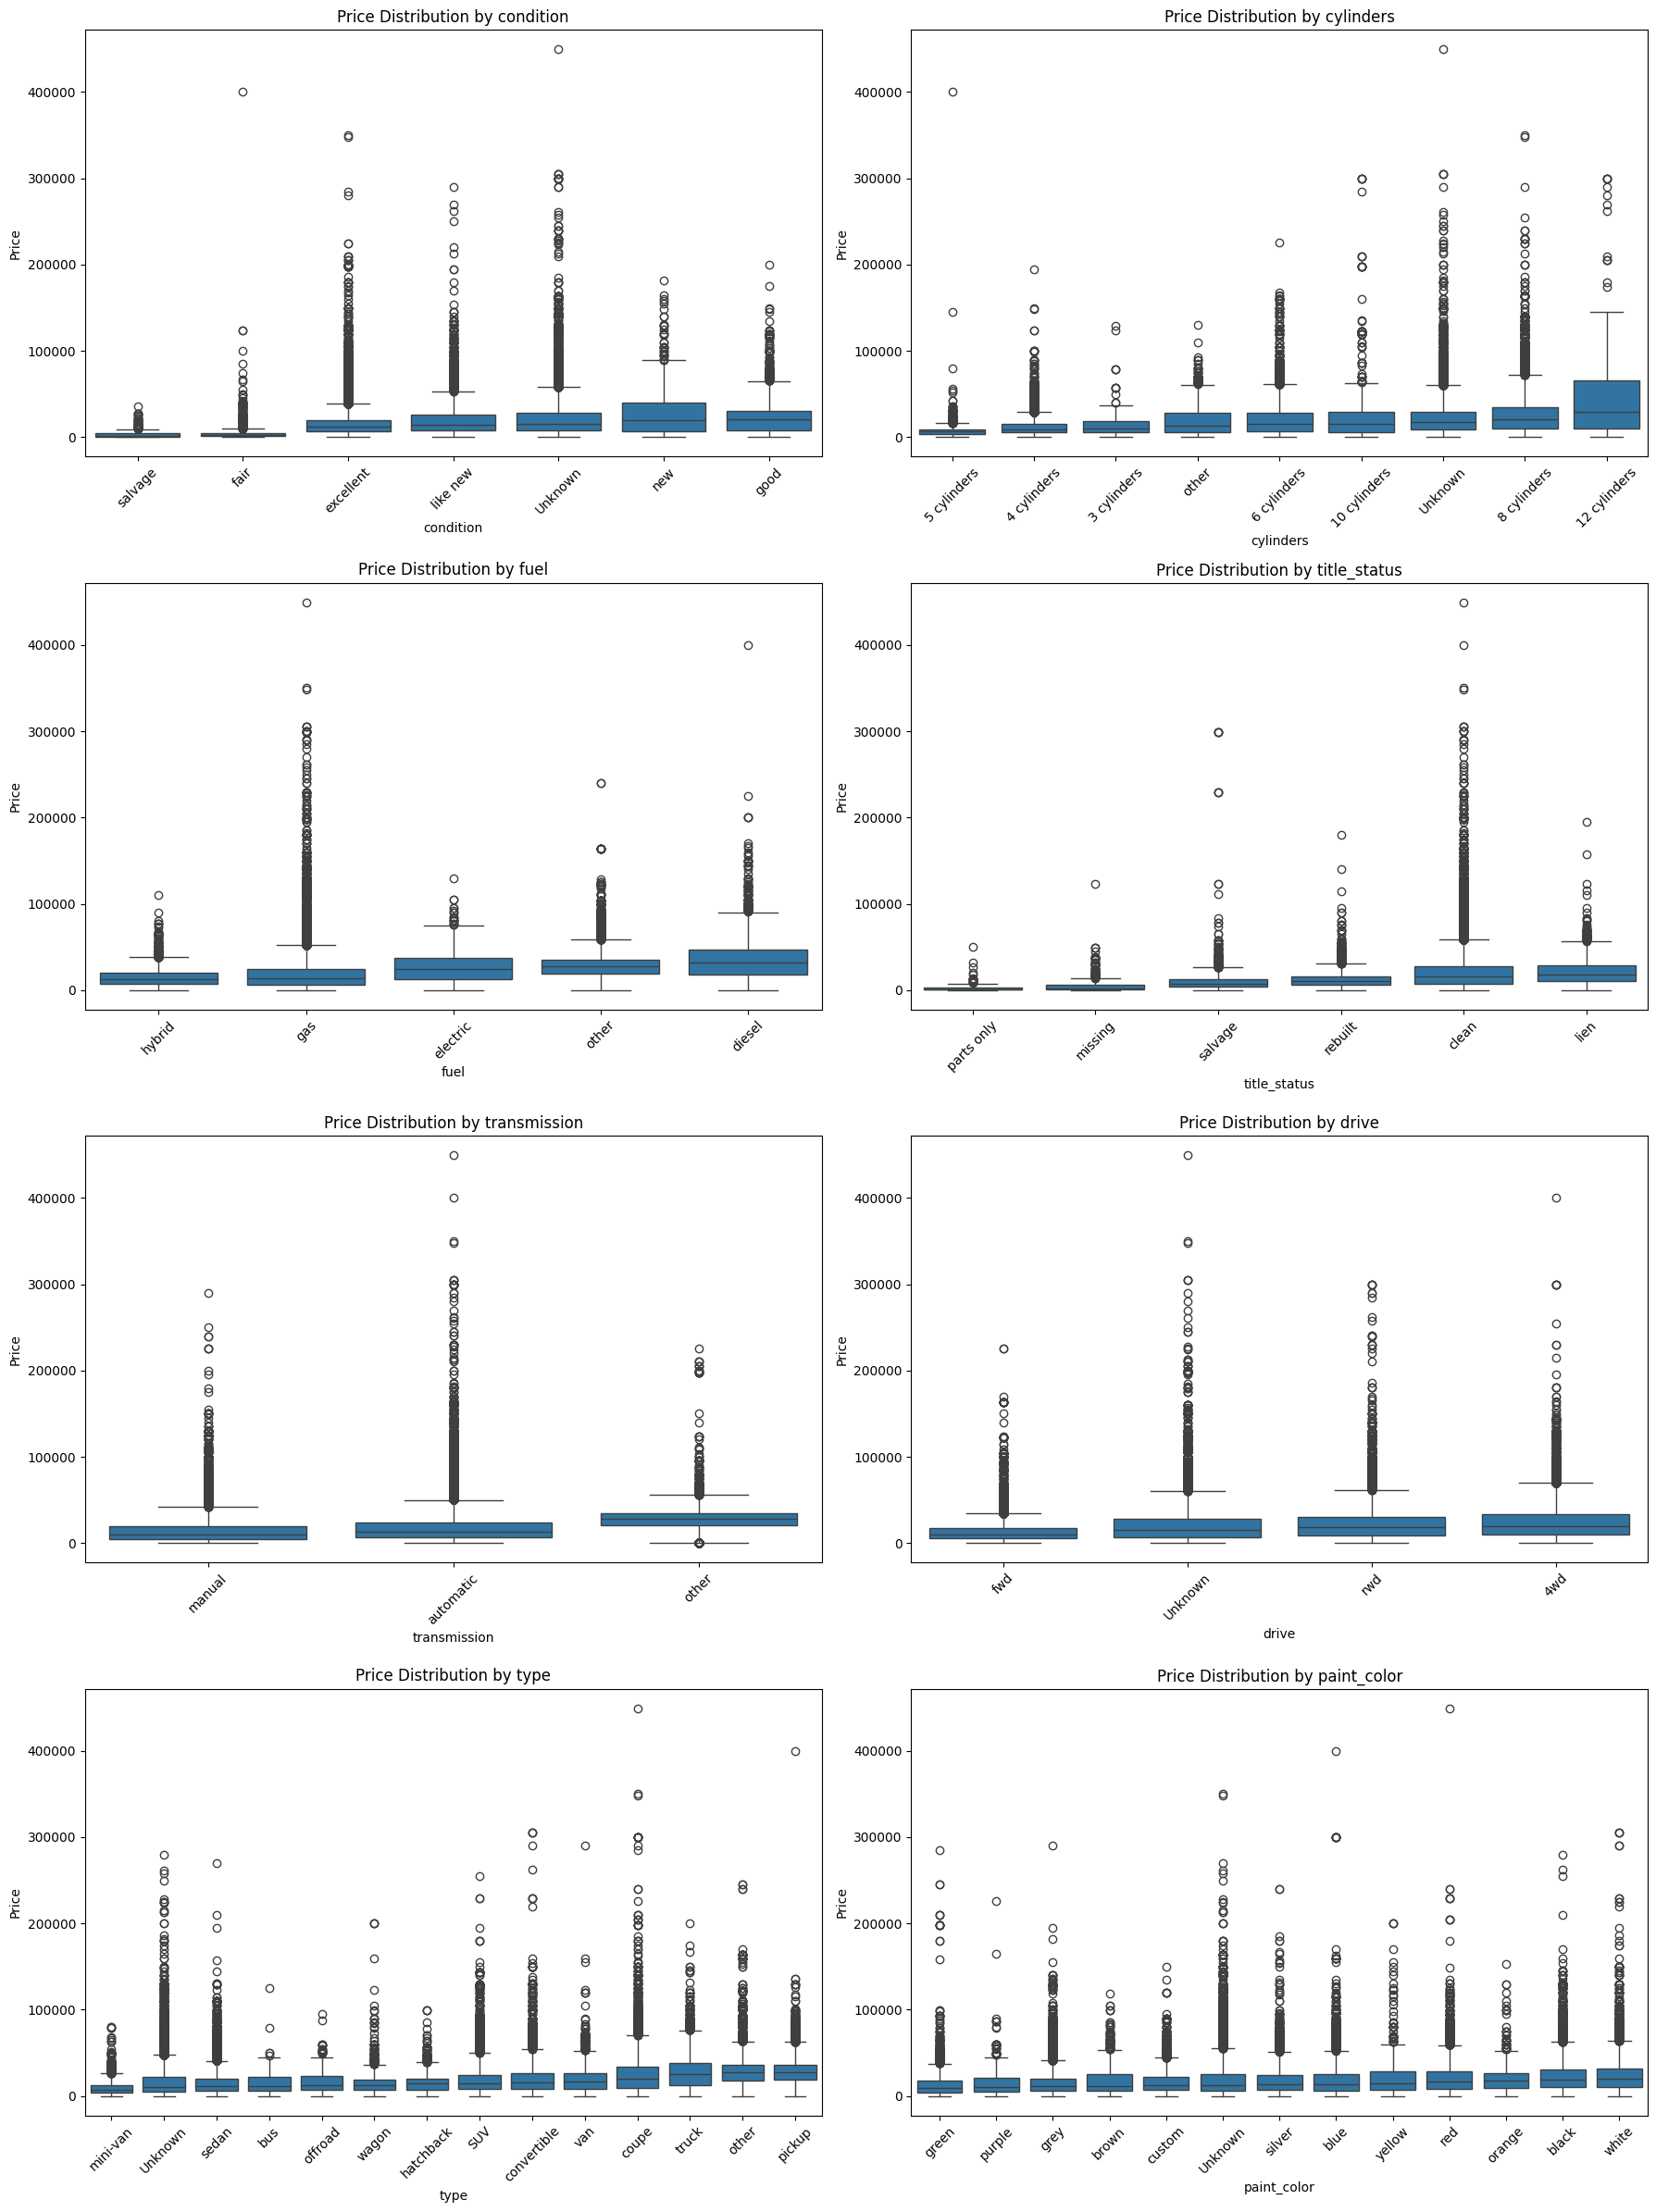

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'type',
    'paint_color'
]

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Sort categories by median price
    order = (
        df.groupby(col)["price"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=df,
        x=col,
        y="price",
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f"Price Distribution by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Price")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [108]:
numerical_cols = [
    "price",
    "year",
    "odometer"
]

correlation = df[numerical_cols].corr()

correlation

,price,year,odometer
price,1.00,0.32,-0.42
year,0.32,1.00,-0.30
odometer,-0.42,-0.30,1.00


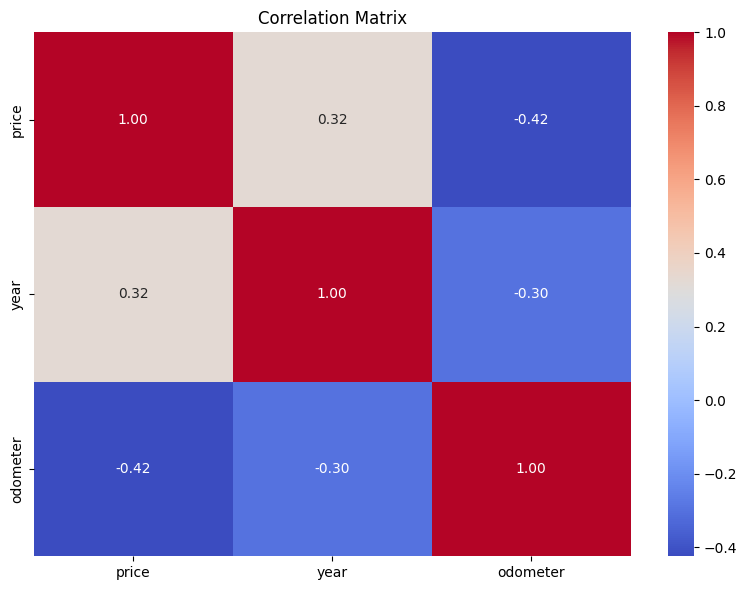

In [109]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

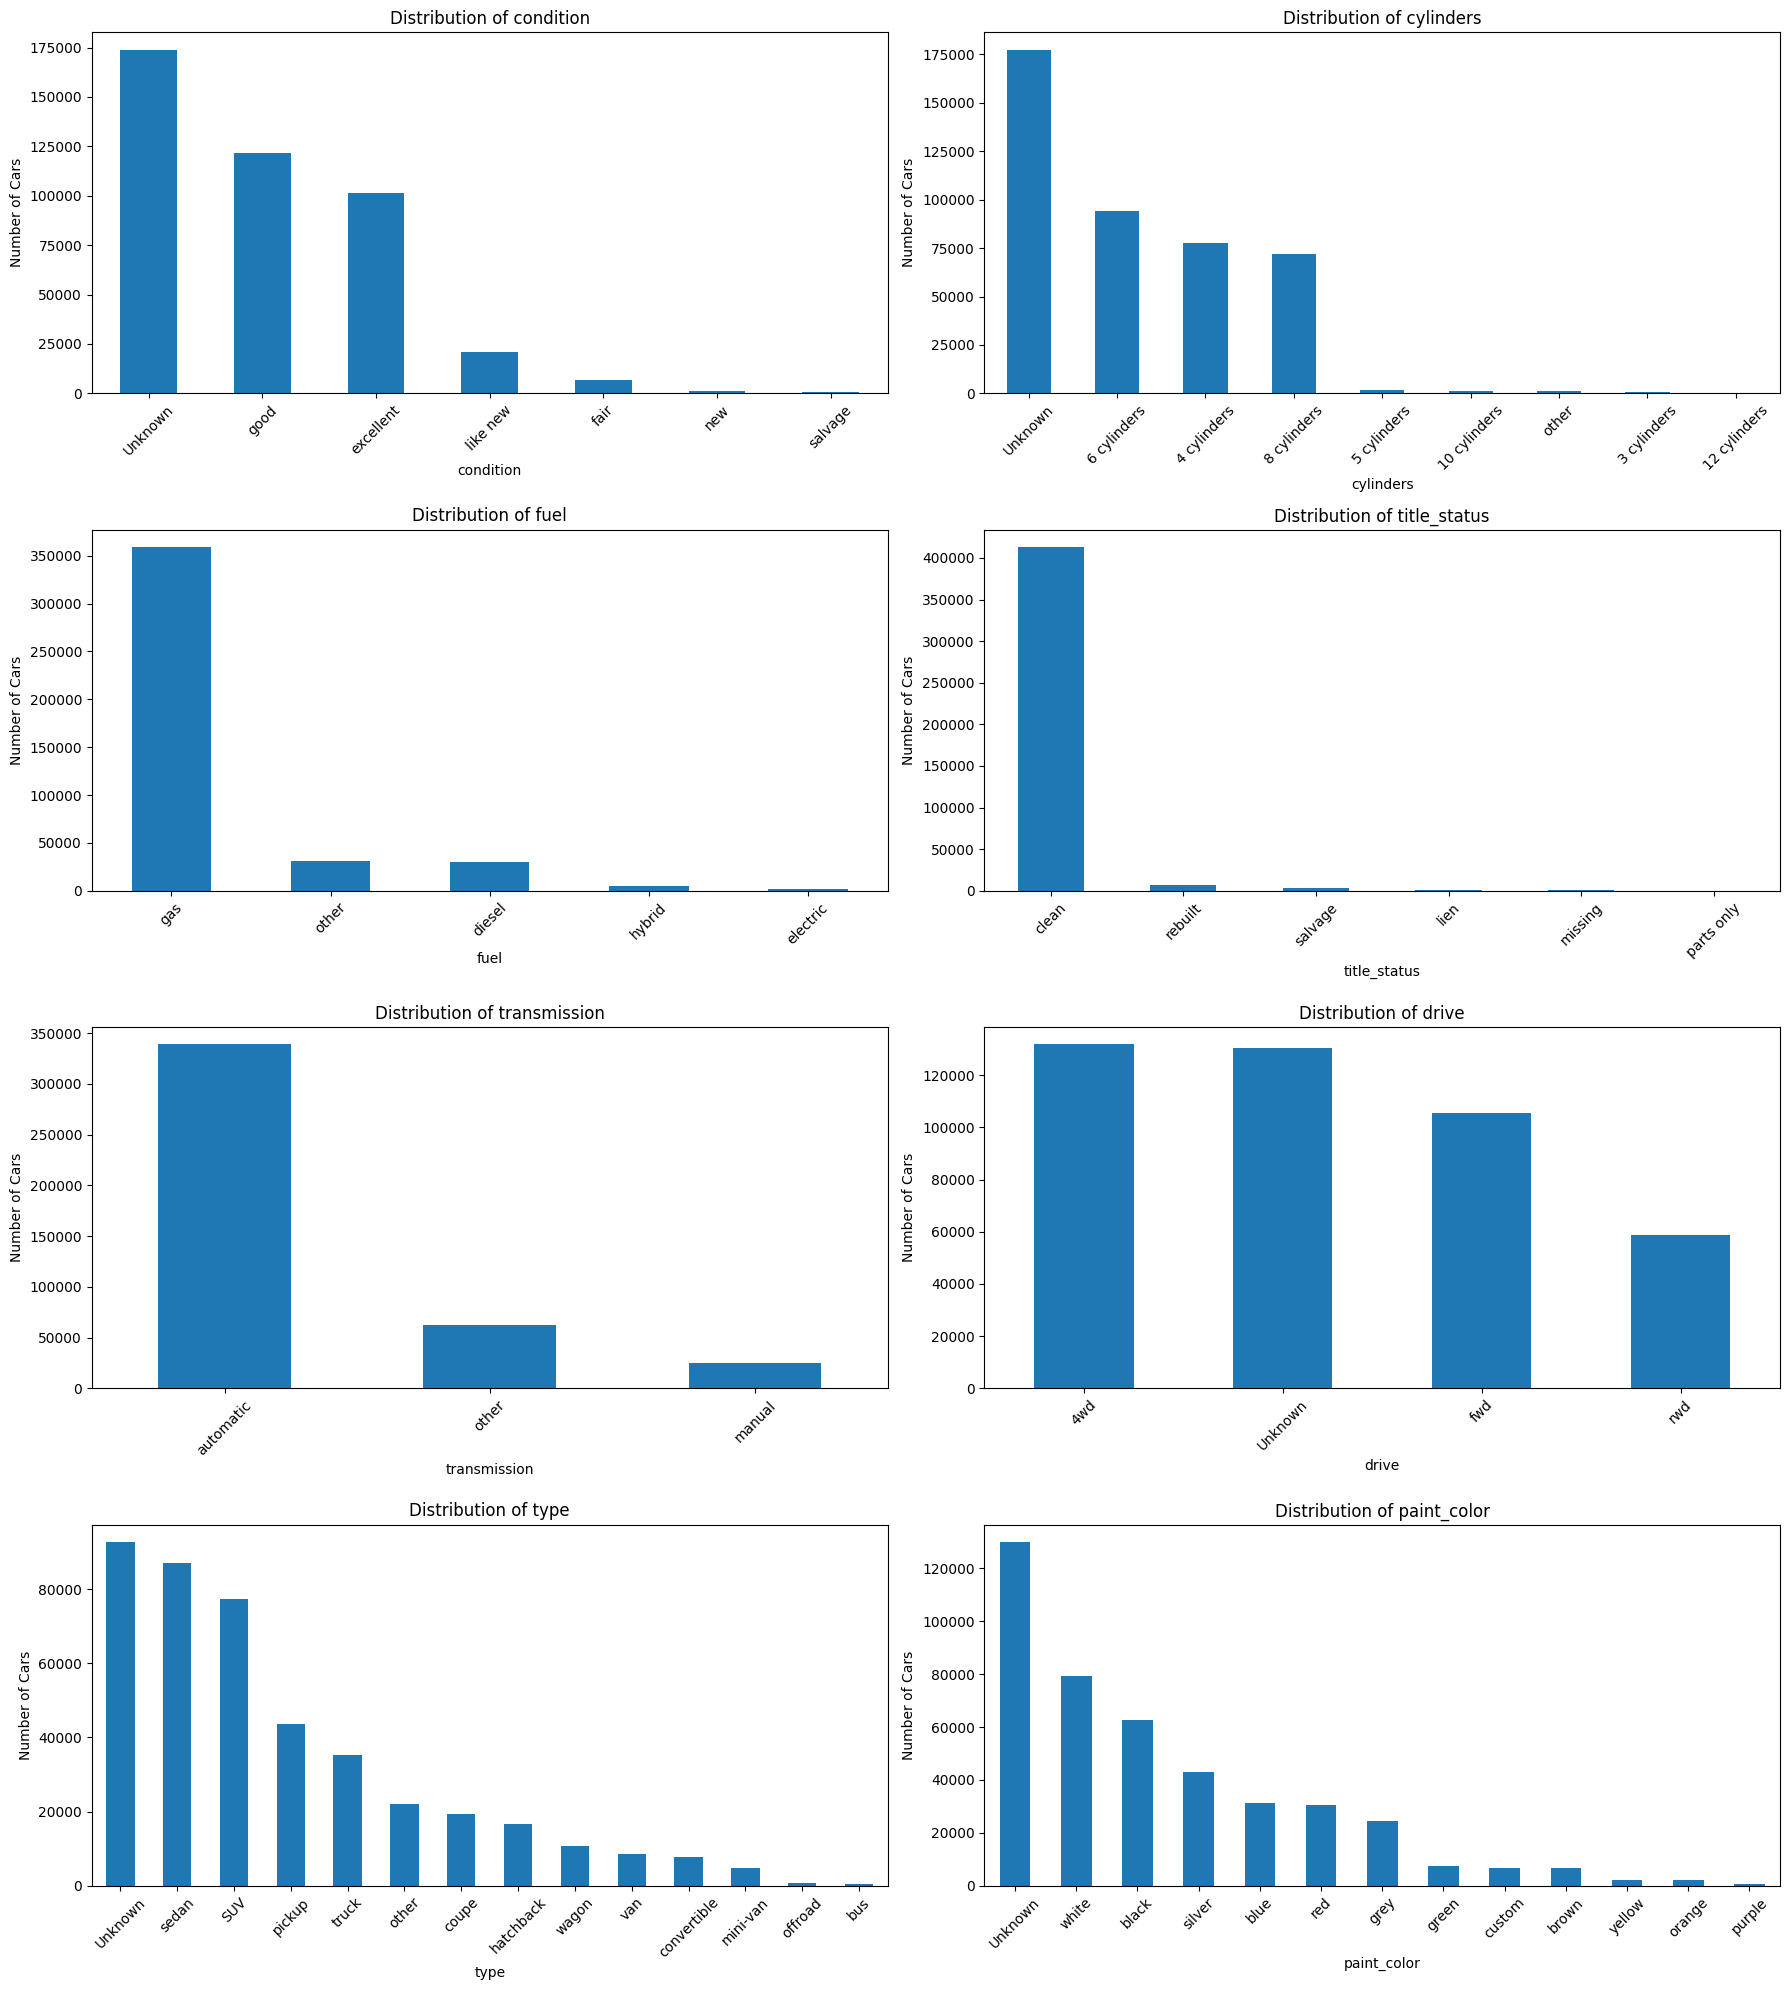

In [110]:
categorical_cols = [
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    counts = df[col].value_counts()

    counts.plot(kind="bar", ax=axes[i])

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Cars")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Final EDA Insights

- The `price` feature is highly right-skewed, with a skewness of approximately 2.27.
- Most cars have prices below 50,000, while a small number of cars have much higher prices.
- `year` has a positive relationship with `price`, with a correlation of 0.32.
- `odometer` has a negative relationship with `price`, with a correlation of -0.42.
- `year` and `odometer` have a moderate negative correlation of -0.30, meaning newer cars tend to have lower mileage.
- Several categorical features are imbalanced, such as `fuel`, `title_status`, and `transmission`.
- Missing values in selected categorical features were represented as an `Unknown` category.
- Extreme values in `price`, `year`, and `odometer` were inspected using both statistical methods and domain knowledge.
- Invalid or suspicious values were handled based on the characteristics of the dataset rather than being removed only because they were statistical outliers.

## Feature Engineering

In [111]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

### posting_date

In [112]:
df["posting_date"].describe()

count                       426714
unique                      381470
top       2021-04-23T22:13:05-0400
freq                            12
Name: posting_date, dtype: object

In [118]:
df["posting_date"].min(), df["posting_date"].max()

(Timestamp('2021-04-04 02:03:15-0500', tz='UTC-05:00'),
 Timestamp('2021-05-04 23:24:09-0500', tz='UTC-05:00'))

In [121]:
df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")

In [122]:
df["posting_date"].dt.year.value_counts().sort_index()

posting_date
2,021.00    100096
Name: count, dtype: int64

In [123]:
# Useless
df.drop(columns=["posting_date"], inplace=True)
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state'],
      dtype='object')

In [124]:
task = {
    'columns': ['posting_date'],
    'action': 'drop from feaures'
}

append_to_do (task)

In [125]:
feature_info = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.values,
    "unique_values": df.nunique().values,
    "missing_values": df.isna().sum().values
})

feature_info

,feature,dtype,unique_values,missing_values
0,region,object,404,0
1,price,float64,15618,32888
2,year,float64,112,0
3,manufacturer,object,42,0
4,model,object,29604,0
5,condition,object,7,0
6,cylinders,object,9,0
7,fuel,object,5,0
8,odometer,float64,104659,0
9,title_status,object,6,0


In [134]:
numerical_features = ["year", "odometer"]

In [135]:
df[["price", "year", "odometer"]].corr()["price"].sort_values(ascending=False)

price       1.00
year        0.32
odometer   -0.42
Name: price, dtype: float64

In [136]:
categorical_features = [
    "region",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state"
]

In [137]:
manufacturer_price = (
    df.groupby("manufacturer")["price"]
      .mean()
      .sort_values(ascending=False)
)

manufacturer_price

manufacturer
ferrari           126,008.40
aston-martin       61,136.62
tesla              39,305.39
porsche            33,905.94
ram                29,859.75
alfa-romeo         29,113.68
rover              28,834.07
jaguar             27,163.35
gmc                24,978.67
audi               24,865.23
mercedes-benz      22,215.23
infiniti           21,010.06
ford               20,848.79
acura              20,785.12
cadillac           20,519.12
lincoln            20,412.61
lexus              20,344.98
bmw                20,343.30
chevrolet          19,946.07
jeep               19,642.27
volvo              18,377.17
toyota             17,072.78
dodge              15,973.34
buick              15,219.85
datsun             15,149.67
land rover         15,103.00
mini               14,890.45
mitsubishi         14,552.01
subaru             13,795.02
harley-davidson    13,448.25
mazda              13,272.51
volkswagen         13,168.38
morgan             13,100.00
nissan             12,874.31
k

In [138]:
df.groupby("condition")["price"].mean().sort_values(ascending=False)

condition
new         27,272.73
good        20,968.22
Unknown     20,006.36
like new    19,248.72
excellent   15,513.79
fair         4,094.01
salvage      3,641.89
Name: price, dtype: float64

In [139]:
df.groupby("cylinders")["price"].mean().sort_values(ascending=False)

cylinders
12 cylinders   53,357.50
8 cylinders    23,935.20
10 cylinders   22,529.77
Unknown        20,652.53
other          20,506.82
6 cylinders    18,461.24
3 cylinders    13,139.53
4 cylinders    11,092.68
5 cylinders     8,040.02
Name: price, dtype: float64

In [140]:
df.groupby("fuel")["price"].mean().sort_values(ascending=False)

fuel
diesel     33,680.71
other      27,896.95
electric   25,739.80
gas        16,990.26
hybrid     15,430.04
Name: price, dtype: float64

In [141]:
df.groupby("title_status")["price"].mean().sort_values(ascending=False)

title_status
lien         22,064.81
clean        19,126.66
rebuilt      12,880.86
salvage      10,094.25
missing       5,143.91
parts only    3,250.14
Name: price, dtype: float64

In [142]:
df.groupby("transmission")["price"].mean().sort_values(ascending=False)

transmission
other       28,044.21
automatic   17,378.01
manual      15,027.03
Name: price, dtype: float64

In [143]:
df.groupby("drive")["price"].mean().sort_values(ascending=False)

drive
4wd       23,426.43
rwd       21,071.14
Unknown   18,440.63
fwd       12,645.54
Name: price, dtype: float64

In [144]:
df.groupby("type")["price"].mean().sort_values(ascending=False)

type
pickup        28,659.92
other         27,531.04
truck         27,016.74
coupe         23,070.22
convertible   20,718.08
van           18,746.42
SUV           17,574.50
offroad       16,239.75
Unknown       15,614.29
hatchback     15,001.08
bus           14,614.44
wagon         14,180.03
sedan         14,149.76
mini-van       9,787.89
Name: price, dtype: float64

In [145]:
df.groupby("paint_color")["price"].mean().sort_values(ascending=False)

paint_color
white     22,534.49
black     21,842.44
red       19,531.77
orange    19,386.61
yellow    19,265.00
Unknown   17,407.60
blue      17,234.94
silver    16,801.68
brown     16,163.77
custom    16,074.23
grey      15,715.28
purple    15,573.84
green     13,430.63
Name: price, dtype: float64

In [146]:
df.groupby("state")["price"].mean().sort_values(ascending=False)

state
ut   25,634.97
wv   25,505.41
wa   24,694.88
mt   24,511.82
ak   24,001.45
mo   22,730.13
wy   22,466.82
ar   22,367.96
nm   21,823.43
id   21,643.80
ok   21,563.45
nv   21,468.78
hi   21,395.64
al   21,170.05
tx   21,112.50
sc   21,067.47
la   20,767.79
az   20,549.79
tn   20,426.19
ga   20,287.49
ks   19,792.91
in   19,789.56
nc   19,702.18
ky   19,480.08
sd   19,319.08
nd   19,247.14
co   19,242.68
ne   18,976.36
md   18,931.90
or   18,810.44
ca   18,630.94
ny   18,380.03
fl   18,308.40
il   17,385.80
ms   17,246.02
ia   17,210.93
va   17,012.57
vt   16,936.29
wi   16,784.97
ri   16,704.92
mn   16,697.31
de   16,411.82
pa   16,319.91
dc   16,149.45
oh   16,063.50
ma   15,937.06
nh   15,810.59
mi   15,804.40
nj   15,599.80
ct   15,062.96
me   14,811.51
Name: price, dtype: float64

In [147]:
df.groupby("region")["price"].mean().sort_values(ascending=False).head (50)

region
logan                      33,941.92
salt lake city             33,651.37
olympic peninsula          33,256.72
east oregon                32,695.96
scottsbluff / panhandle    32,502.30
boone                      31,353.31
yuma                       31,099.25
pullman / moscow           31,066.40
southwest TX               30,607.17
butte                      30,557.01
laredo                     30,177.90
san angelo                 29,742.06
owensboro                  29,650.40
galveston                  29,416.80
northwest KS               29,256.74
moses lake                 29,182.75
wenatchee                  29,143.75
southwest VA               29,123.49
central louisiana          29,095.19
stillwater                 29,055.77
bakersfield                28,462.40
tuscaloosa                 27,787.43
abilene                    27,773.70
wichita falls              27,745.31
northwest OK               27,557.36
visalia-tulare             27,529.40
chillicothe                27,4

In [148]:
df.groupby("region")["price"].mean().sort_values().head (50)

region
siskiyou county            9,178.53
west virginia (old)        9,423.75
show low                  10,634.49
kenosha-racine            10,686.84
high rockies              11,162.59
fort smith, AR            11,471.88
klamath falls             11,534.18
philadelphia              11,954.02
upper peninsula           12,527.31
detroit metro             12,638.65
houma                     12,840.69
duluth / superior         13,198.76
chicago                   13,208.59
battle creek              13,237.80
milwaukee                 13,243.57
potsdam-canton-massena    13,302.37
new haven                 13,571.94
norfolk / hampton roads   13,651.13
okaloosa / walton         13,670.68
mendocino county          13,813.84
salem                     13,819.33
flint                     13,849.69
lansing                   14,131.89
sioux city                14,203.67
akron / canton            14,213.57
south florida             14,292.76
cleveland                 14,414.34
north jersey         

In [149]:
df.groupby("model")["price"].mean().sort_values(ascending=False).head(50)

model
f8 tributo                                             348,999.00
Lamborghini Aventador                                  299,500.00
488 gtb                                                289,371.25
Lamborghini huracan evo                                285,000.00
rolls royce dawn                                       279,888.00
ROLLS ROYCE GHOST                                      269,950.00
Rolls royce dawn                                       261,895.00
McLaren 720S Performance                               260,995.00
lamborghini urus                                       257,995.00
g550 square                                            255,000.00
panamera turbo st                                      244,999.00
488 spider                                             244,600.00
911 gt3 touring                                        239,900.00
Lamborghini Urus                                       229,500.00
f12berlinetta                                          226,248.00
2 dr

In [150]:
df.groupby("model")["price"].mean().sort_values().head(50)

model
5 window                     1.00
taurus eco-boost             1.00
fusion buy here pay here     1.00
1992 Freightliner            1.00
/ bertone x1/9               1.00
Custom                       1.00
3500 with crane              1.00
buy here pay here            1.00
Bridgestone + Mastercraft    1.00
anglia                       1.00
and newer                    1.00
2004 Freightliner FL80       1.00
taurus x awd                 1.00
Autos                        1.00
550 maranello                1.00
snata fe                     1.00
fairmont                     1.00
Fisher/Daniels               1.00
lamborghini countach         1.00
cyclone cj428                1.00
all make                     1.00
2005 LeSabre                 1.00
handicap vans                1.00
1991 Volkwagen Transporter   1.00
Mac Value                    1.00
dart gt sporty               1.00
triumph gt6                  1.00
rx 7                         1.00
fe-160g                      1.00
fe-140g 

### Keep them all 🤷‍♂️🙂

In [151]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state'],
      dtype='object')

## Train / Test Split

In [152]:
for x in to_do:
    pprint (x)
    print ('-' * 20)
    print ()

{'action': 'drop useless columns',
 'columns': ['id',
             'url',
             'region_url',
             'VIN',
             'image_url',
             'description',
             'county',
             'lat',
             'long']}
--------------------

{'action': 'drop duplicates',
 'columns': ['region',
             'price',
             'year',
             'manufacturer',
             'model',
             'condition',
             'cylinders',
             'fuel',
             'odometer',
             'title_status',
             'transmission',
             'drive',
             'size',
             'type',
             'paint_color',
             'state',
             'posting_date']}
--------------------

{'action': 'df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan',
 'columns': ['odometer']}
--------------------

{'action': 'df.loc[df["year"] == 1900, "year"] = np.nan', 'columns': ['year']}
--------------------

{'action': 'fill missing values with median', 'co

In [159]:
# df = pd.read_csv ("../data/vehicles.csv")
df = pd.read_csv ('/kaggle/input/datasets/austinreese/craigslist-carstrucks-data/vehicles.csv') # Kaggle
print (df.shape)
df.columns

(426880, 26)


Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [160]:
columns_to_drop = [
    "id",
    "url",
    "region_url",
    "VIN",
    "image_url",
    "description",
    "county",
    "lat",
    "long",
    "posting_date"
]

df = df.drop(columns=columns_to_drop)

df.shape

(426880, 16)

## Preprocessing

### Handle invalid odometer values

Convert suspicious odometer values to missing values.

In [164]:
df.loc[df["odometer"] >= 1_000_000, "odometer"] = np.nan

### Remove duplicate rows

Remove fully duplicated car records from the dataset.

In [165]:
df = df.drop_duplicates()
df.shape

(370463, 16)

### Handle zero prices

Convert zero prices to missing values because they are not valid target values.

In [166]:
df.loc[df["price"] == 0, "price"] = np.nan

In [167]:
df["price"].isna().sum()

np.int64(25688)

### Clean invalid model values

Replace predefined invalid model values with missing values.

In [168]:
df.loc[df["model"].isin(missing_values), "model"] = np.nan

In [169]:
df["model"].isna().sum()

np.int64(5005)

### Remove extreme price values

Remove rows where the price is greater than 500,000.

In [170]:
df = df[(df["price"] <= 500_000) | (df["price"].isna())]

### Check suspicious rows

Check whether the suspicious row indices still exist in the DataFrame.

In [171]:
df.loc[df.index.intersection ([113357, 133497]), ["price"]]

,price
113357,"470,000.00"
133497,"425,000.00"


In [172]:
df = df.drop (index=[113357, 133497])

In [174]:
df = df.dropna (subset=["price"])
df.shape

(344720, 16)

In [176]:
X = df.drop (columns=["price"])
y = df ["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [178]:
numeric_features = ["year", "odometer"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [179]:
mode_features = [
    "manufacturer",
    "fuel",
    "title_status",
    "transmission"
]

categorical_mode_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

In [180]:
unknown_features = [
    "model",
    "condition",
    "cylinders",
    "drive",
    "type",
    "paint_color"
]

categorical_unknown_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown"))
])

In [181]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical_mode", categorical_mode_pipeline, mode_features),
    ("categorical_unknown", categorical_unknown_pipeline, unknown_features)
])

## Encode
### Analyze categorical features

Check the number of unique values and the categories of each categorical feature.

In [186]:
categorical_features = [
    "region",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "size",
    "type",
    "paint_color",
    "state"
]

X_train[categorical_features].nunique().sort_values(ascending=False)

model           24825
region            404
state              51
manufacturer       42
type               13
paint_color        12
cylinders           8
condition           6
title_status        6
fuel                5
size                4
drive               3
transmission        3
dtype: int64

In [190]:
categorical_features = X_train.select_dtypes(include="object").columns

for col in categorical_features:
    print(f"\n{col}")
    print(f"Unique values: {X_train[col].nunique(dropna=False)}")
    print(X_train[col].value_counts(dropna=False).head(10))


region
Unique values: 404
region
denver                   2216
minneapolis / st paul    2206
chicago                  2179
central NJ               2172
portland                 2152
columbus                 2147
boston                   2135
north jersey             2110
ft myers / SW florida    2102
las vegas                2095
Name: count, dtype: int64

manufacturer
Unique values: 43
manufacturer
ford         45137
chevrolet    35355
toyota       22079
honda        13746
jeep         12009
nissan       11891
NaN          11471
ram          11261
gmc          10790
bmw           9709
Name: count, dtype: int64

model
Unique values: 24826
model
f-150             4689
NaN               3575
silverado 1500    2964
1500              2472
accord            1884
camry             1879
silverado         1874
civic             1753
escape            1689
2500              1646
Name: count, dtype: int64

condition
Unique values: 7
condition
NaN          98958
good         91516
excellent    

### Define categorical encoding pipelines

Create separate pipelines for target, ordinal, and one-hot encoding.

In [192]:
# Target Encoding
target_features = [
    "model",
    "region",
    "manufacturer",
    "state"
]

target_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", TargetEncoder(
        handle_missing="value",
        handle_unknown="value",
        smoothing=10
    ))
])


# Ordinal Encoding
ordinal_features = [
    "condition",
    "size"
]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["salvage", "fair", "good", "excellent", "like new", "new", "Unknown"],
            ["sub-compact", "compact", "mid-size", "full-size", "Unknown"]
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


# One-Hot Encoding
onehot_features = [
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

### Build the final preprocessing transformer

Combine imputation and encoding for all numeric and categorical features.

In [193]:
# -----------------------------
# Numeric features
# -----------------------------

numeric_features = [
    "year",
    "odometer"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# -----------------------------
# Target Encoding
# -----------------------------

target_features = [
    "model",
    "region",
    "manufacturer",
    "state"
]

target_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", TargetEncoder(
        handle_missing="value",
        handle_unknown="value",
        smoothing=10
    ))
])


# -----------------------------
# Ordinal Encoding
# -----------------------------

ordinal_features = [
    "condition",
    "size"
]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", OrdinalEncoder(
        categories=[
            [
                "salvage",
                "fair",
                "good",
                "excellent",
                "like new",
                "new"
            ],
            [
                "sub-compact",
                "compact",
                "mid-size",
                "full-size"
            ]
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])


# -----------------------------
# One-Hot Encoding
# -----------------------------

onehot_features = [
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# -----------------------------
# Final ColumnTransformer
# -----------------------------

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("target", target_pipeline, target_features),
    ("ordinal", ordinal_pipeline, ordinal_features),
    ("onehot", onehot_pipeline, onehot_features)
])

In [195]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

## Apply Preprocessing & Train Baseline Model

In [196]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['year', 'odometer']),
                                                 ('target',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   TargetEncoder())]),
                                                  ['model', 'region',
                                                   'manufacturer', 'state']),
                                                 ('ordinal',
                                                  Pipeline(step...
                                                                                  unknown_value=-1))]),
                                                  ['condition', 'size']),
                                                 ('onehot',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'type', 'paint_color'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

### Make predictions

Use the trained pipeline to predict car prices for the test data.

In [197]:
y_pred = model_pipeline.predict(X_test)

In [198]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 2,796.88
RMSE: 6,499.87
R²: 0.8240


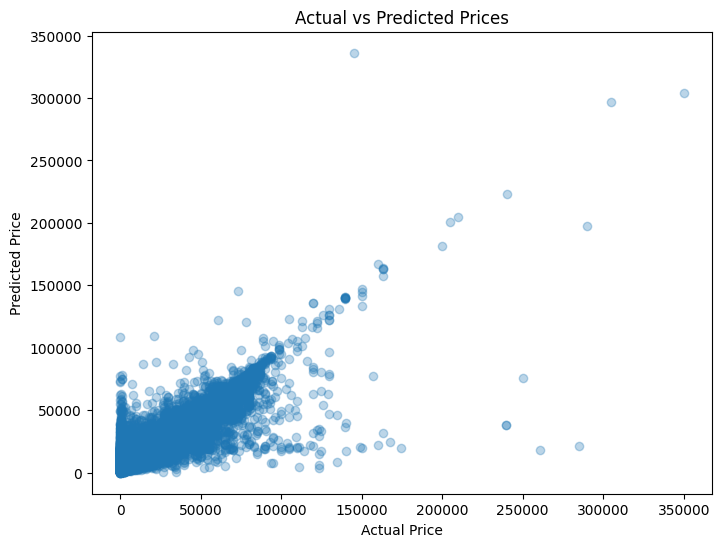

In [199]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()